# # Supporting Information Notebook: Norman Perturb-seq analysis of concept-space structure

This notebook reproduces the analysis for the Norman Perturb-seq dataset used in the manuscript (Results Section 3.5–3.6 and related figures).

**Purpose**
- Compute concept activations  
- Analyze concept-space geometry  
- Evaluate gene-level support  
- Export summary tables for figure generation  

**Analysis framing**
The evaluation is structured around four questions:
1. Does the model retain perturbation signal beyond class imbalance?  
2. Do perturbations induce selective concept fingerprints rather than diffuse activation?  
3. Do related perturbations organize into structured neighborhoods in concept space?  
4. When do concept-level fingerprints also support gene-level mechanistic recovery?  

The interpretation is intentionally conditional: structured concept geometry is reproducible and biologically coherent, but gene-level mechanistic recovery is limited and depends on perturbation type.

---

## Execution modes

This notebook supports two valid execution modes:

**Full training (optional)**
- Run Cells 1–15.  
- Cell 15 trains MM-KPNN with restart-safe checkpointing.  
- This step is computationally intensive (~11+ hours) and not required for reproducing manuscript results.  

**Checkpoint-based reproduction (recommended)**
- Run Cells 1–14, **skip Cell 15**, and continue from Cell 16.  
- Cell 16 reloads the saved best checkpoint.  
- From Cell 16 onward, the workflow is identical to the full-training path.  

This notebook is intended to be executed sequentially from top to bottom.


In [1]:
# === Cell 1: load GSE133344 perturb-seq dataset (fixed obs alignment) ===

import gzip
import pandas as pd
import scanpy as sc

from pathlib import Path
from scipy.io import mmread

project_root = Path.home() / "Desktop" / "MM-KPNN"
data_dir = project_root / "data" / "GSE133344"

print("Project root:", project_root)
print("Dataset dir :", data_dir)

# --------------------------------------------------
# File paths
# --------------------------------------------------
matrix_file = data_dir / "GSE133344_filtered_matrix.mtx.gz"
genes_file = data_dir / "GSE133344_filtered_genes.tsv.gz"
barcodes_file = data_dir / "GSE133344_filtered_barcodes.tsv.gz"
meta_file = data_dir / "GSE133344_filtered_cell_identities.csv.gz"

print("\nFiles")
for f in [matrix_file, genes_file, barcodes_file, meta_file]:
    print(f"{f.name:42s} | {'FOUND' if f.exists() else 'MISSING'}")

# --------------------------------------------------
# Load matrix
# --------------------------------------------------
print("\nLoading expression matrix...")
with gzip.open(matrix_file, "rb") as f:
    X = mmread(f).tocsr()
print("Matrix shape:", X.shape)

# --------------------------------------------------
# Load genes
# --------------------------------------------------
print("\nLoading genes...")
genes = pd.read_csv(
    genes_file,
    sep="\t",
    header=None,
    compression="gzip"
)

print("Raw genes shape:", genes.shape)

if genes.shape[1] == 1:
    genes.columns = ["gene_symbol"]
elif genes.shape[1] == 2:
    genes.columns = ["gene_id", "gene_symbol"]
elif genes.shape[1] >= 3:
    genes = genes.iloc[:, :3].copy()
    genes.columns = ["gene_id", "gene_symbol", "feature_type"]
else:
    raise RuntimeError(f"Unexpected genes file shape: {genes.shape}")

print("Parsed genes columns:", genes.columns.tolist())

# --------------------------------------------------
# Load barcodes
# --------------------------------------------------
print("\nLoading barcodes...")
barcodes = pd.read_csv(
    barcodes_file,
    sep="\t",
    header=None,
    compression="gzip"
)
barcodes.columns = ["cell_barcode"]
barcodes["cell_barcode"] = barcodes["cell_barcode"].astype(str)
print("Barcodes:", barcodes.shape)

# --------------------------------------------------
# Load metadata
# --------------------------------------------------
print("\nLoading cell metadata...")
cell_meta = pd.read_csv(
    meta_file,
    compression="gzip"
)
cell_meta["cell_barcode"] = cell_meta["cell_barcode"].astype(str)

print("Metadata:", cell_meta.shape)
print("\nMetadata columns:")
print(cell_meta.columns.tolist())

# --------------------------------------------------
# Align obs to full barcode list
# --------------------------------------------------
obs = barcodes.merge(cell_meta, on="cell_barcode", how="left")

print("\nAligned obs shape:", obs.shape)
print("Cells with metadata:", obs["guide_identity"].notna().sum())
print("Cells missing metadata:", obs["guide_identity"].isna().sum())

# --------------------------------------------------
# Sanity checks
# --------------------------------------------------
n_genes_matrix, n_cells_matrix = X.shape

if n_cells_matrix != len(obs):
    raise RuntimeError(
        f"Cell mismatch after obs alignment: matrix has {n_cells_matrix} cells, obs has {len(obs)} rows"
    )

if n_genes_matrix != len(genes):
    raise RuntimeError(
        f"Gene mismatch: matrix has {n_genes_matrix} genes, genes table has {len(genes)} rows"
    )

# --------------------------------------------------
# Assemble AnnData
# --------------------------------------------------
adata = sc.AnnData(
    X=X.T,
    obs=obs.copy(),
    var=genes.copy(),
    dtype=X.dtype
)

adata.obs_names = obs["cell_barcode"].astype(str).values
adata.var_names = genes["gene_symbol"].astype(str).values
adata.var_names_make_unique()

print("\nAnnData object")
print(adata)


Project root: /Users/sally/Desktop/MM-KPNN
Dataset dir : /Users/sally/Desktop/MM-KPNN/data/GSE133344

Files
GSE133344_filtered_matrix.mtx.gz           | FOUND
GSE133344_filtered_genes.tsv.gz            | FOUND
GSE133344_filtered_barcodes.tsv.gz         | FOUND
GSE133344_filtered_cell_identities.csv.gz  | FOUND

Loading expression matrix...
Matrix shape: (33694, 111668)

Loading genes...
Raw genes shape: (33694, 2)
Parsed genes columns: ['gene_id', 'gene_symbol']

Loading barcodes...
Barcodes: (111668, 1)

Loading cell metadata...
Metadata: (111445, 8)

Metadata columns:
['cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells']

Aligned obs shape: (111668, 8)
Cells with metadata: 111445
Cells missing metadata: 223

AnnData object
AnnData object with n_obs × n_vars = 111668 × 33694
    obs: 'cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells'
    var: 'gene_i

/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [2]:
# === Cell 2: audit perturbation labels and metadata structure ===

import pandas as pd
import numpy as np

print("AnnData summary")
print(adata)

print("\nObs columns")
print(adata.obs.columns.tolist())

# --------------------------------------------------
# Missing guide labels
# --------------------------------------------------
missing_guides = adata.obs["guide_identity"].isna().sum()
print("\nCells with missing guide_identity:", missing_guides)

# --------------------------------------------------
# Unique perturbations
# --------------------------------------------------
guides = adata.obs["guide_identity"].dropna().astype(str)

print("\nUnique perturbation identities:", guides.nunique())

print("\nExample perturbation labels:")
print(sorted(guides.unique())[:20])

# --------------------------------------------------
# Cell counts per perturbation
# --------------------------------------------------
guide_counts = guides.value_counts()

print("\nTop perturbations by cell count")
print(guide_counts.head(20))

print("\nSmallest perturbations")
print(guide_counts.tail(20))

print("\nTotal perturbation labels:", len(guide_counts))

# --------------------------------------------------
# Detect combinatorial perturbations
# --------------------------------------------------
# Norman dataset often encodes dual guides with "+"
is_combo = guides.str.contains(r"\+", regex=True)

n_combo = is_combo.sum()
n_single = (~is_combo).sum()

print("\nSingle perturbation cells:", n_single)
print("Combinatorial perturbation cells:", n_combo)

combo_labels = guides[is_combo].unique()

print("\nExample combinatorial labels:")
print(sorted(combo_labels)[:20])

# --------------------------------------------------
# Detect control guides
# --------------------------------------------------
control_candidates = guides[
    guides.str.contains("ctrl|control|NT|non", case=False, regex=True)
]

print("\nPossible control labels:")
print(control_candidates.unique())

# --------------------------------------------------
# Summary statistics
# --------------------------------------------------
print("\nGuide count distribution")
print(guide_counts.describe())

AnnData summary
AnnData object with n_obs × n_vars = 111668 × 33694
    obs: 'cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells'
    var: 'gene_id', 'gene_symbol'

Obs columns
['cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells']

Cells with missing guide_identity: 223

Unique perturbation identities: 290

Example perturbation labels:
['AHR_FEV__AHR_FEV', 'AHR_KLF1__AHR_KLF1', 'AHR_NegCtrl0__AHR_NegCtrl0', 'ARID1A_NegCtrl0__ARID1A_NegCtrl0', 'ARRDC3_NegCtrl0__ARRDC3_NegCtrl0', 'ATL1_NegCtrl0__ATL1_NegCtrl0', 'BAK1_NegCtrl0__BAK1_NegCtrl0', 'BCL2L11_BAK1__BCL2L11_BAK1', 'BCL2L11_NegCtrl0__BCL2L11_NegCtrl0', 'BCL2L11_TGFBR2__BCL2L11_TGFBR2', 'BCORL1_NegCtrl0__BCORL1_NegCtrl0', 'BPGM_NegCtrl0__BPGM_NegCtrl0', 'BPGM_SAMD1__BPGM_SAMD1', 'BPGM_ZBTB1__BPGM_ZBTB1', 'C19orf26_NegCtrl0__C19orf26_NegCtrl0', 'C3orf72_FOXL2__C3orf72_FOXL2', 'C3orf72_NegCtrl0__C3orf

In [3]:
# === Cell 3: parse perturbation structure ===

import pandas as pd
import numpy as np

# --------------------------------------------------
# Extract perturbation pair
# --------------------------------------------------
guide_raw = adata.obs["guide_identity"].astype(str)

# keep only the left part of "__"
guide_pair = guide_raw.str.split("__").str[0]

# split geneA_geneB
guide_a = guide_pair.str.split("_").str[0]
guide_b = guide_pair.str.split("_").str[1]

adata.obs["perturb_A"] = guide_a
adata.obs["perturb_B"] = guide_b

print("Parsed perturbation columns added.")

# --------------------------------------------------
# Detect control guides
# --------------------------------------------------
is_ctrl_A = adata.obs["perturb_A"].str.contains("NegCtrl", na=False)
is_ctrl_B = adata.obs["perturb_B"].str.contains("NegCtrl", na=False)

# --------------------------------------------------
# Define perturbation regimes
# --------------------------------------------------
adata.obs["perturbation_type"] = "unknown"

adata.obs.loc[is_ctrl_A & is_ctrl_B, "perturbation_type"] = "control"

adata.obs.loc[
    (~is_ctrl_A & is_ctrl_B) | (is_ctrl_A & ~is_ctrl_B),
    "perturbation_type"
] = "single"

adata.obs.loc[
    (~is_ctrl_A & ~is_ctrl_B),
    "perturbation_type"
] = "double"

# --------------------------------------------------
# Summary statistics
# --------------------------------------------------
print("\nPerturbation regimes")
print(adata.obs["perturbation_type"].value_counts())

# --------------------------------------------------
# Unique genes perturbed
# --------------------------------------------------
single_cells = adata.obs["perturbation_type"] == "single"

single_genes = pd.concat([
    adata.obs.loc[single_cells, "perturb_A"],
    adata.obs.loc[single_cells, "perturb_B"]
])

single_genes = single_genes[~single_genes.str.contains("NegCtrl")]

print("\nUnique single-perturbed genes:", single_genes.nunique())

print("\nExample single perturbations:")
print(sorted(single_genes.unique())[:20])

# --------------------------------------------------
# Cells per perturbation gene
# --------------------------------------------------
pert_gene = adata.obs.loc[single_cells, ["perturb_A", "perturb_B"]]

pert_gene = pert_gene.apply(
    lambda row: row["perturb_A"] if "NegCtrl" in row["perturb_B"] else row["perturb_B"],
    axis=1
)

counts = pert_gene.value_counts()

print("\nTop perturbed genes")
print(counts.head(20))

print("\nPerturbation cell count distribution")
print(counts.describe())

Parsed perturbation columns added.

Perturbation regimes
perturbation_type
single     57831
double     41982
control    11855
Name: count, dtype: int64

Unique single-perturbed genes: 105

Example single perturbations:
['AHR', 'ARID1A', 'ARRDC3', 'ATL1', 'BAK1', 'BCL2L11', 'BCORL1', 'BPGM', 'C19orf26', 'C3orf72', 'CBFA2T3', 'CBL', 'CDKN1A', 'CDKN1B', 'CDKN1C', 'CEBPA', 'CEBPB', 'CEBPE', 'CELF2', 'CITED1']

Top perturbed genes
KLF1        1960
BAK1        1457
CEBPE       1233
UBASH3B     1202
ETS2        1201
OSR2        1003
SLC4A1      1000
SET          986
ELMSAN1      937
MAP2K6       878
FOXF1        874
C19orf26     872
FOXA1        851
UBASH3A      819
RUNX1T1      779
MEIS1        776
CNN1         765
MAPK1        765
MAP7D1       751
ZBTB25       740
Name: count, dtype: int64

Perturbation cell count distribution
count     105.000000
mean      550.771429
std       291.817786
min       113.000000
25%       331.000000
50%       495.000000
75%       690.000000
max      1960.00000

In [4]:
# === Cell 4: construct single-perturbation benchmark dataset ===

import pandas as pd
import numpy as np

print("Original dataset:", adata)

# --------------------------------------------------
# Keep only single perturbations + controls
# --------------------------------------------------
benchmark_mask = adata.obs["perturbation_type"].isin(["single", "control"])

adata_bench = adata[benchmark_mask].copy()

print("\nBenchmark subset:")
print(adata_bench)

# --------------------------------------------------
# Extract perturbed gene
# --------------------------------------------------
def extract_target(row):
    
    a = row["perturb_A"]
    b = row["perturb_B"]
    
    if "NegCtrl" in a and "NegCtrl" in b:
        return "control"
    
    if "NegCtrl" in a:
        return b
    
    if "NegCtrl" in b:
        return a
    
    return "unknown"

adata_bench.obs["perturb_target"] = adata_bench.obs.apply(
    extract_target,
    axis=1
)

# --------------------------------------------------
# Remove unknowns (should be none)
# --------------------------------------------------
adata_bench = adata_bench[
    adata_bench.obs["perturb_target"] != "unknown"
].copy()

# --------------------------------------------------
# Summary statistics
# --------------------------------------------------
print("\nPerturbation targets:", adata_bench.obs["perturb_target"].nunique())

target_counts = adata_bench.obs["perturb_target"].value_counts()

print("\nTop perturbation targets")
print(target_counts.head(20))

print("\nSmallest perturbation targets")
print(target_counts.tail(20))

print("\nCell count distribution")
print(target_counts.describe())

# --------------------------------------------------
# Store label column
# --------------------------------------------------
adata_bench.obs["label"] = adata_bench.obs["perturb_target"]

print("\nFinal benchmark dataset:")
print(adata_bench)

print("\nUnique labels:", adata_bench.obs["label"].nunique())

Original dataset: AnnData object with n_obs × n_vars = 111668 × 33694
    obs: 'cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'perturb_A', 'perturb_B', 'perturbation_type'
    var: 'gene_id', 'gene_symbol'

Benchmark subset:
AnnData object with n_obs × n_vars = 69686 × 33694
    obs: 'cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'perturb_A', 'perturb_B', 'perturbation_type'
    var: 'gene_id', 'gene_symbol'

Perturbation targets: 106

Top perturbation targets
perturb_target
control     11855
KLF1         1960
BAK1         1457
CEBPE        1233
UBASH3B      1202
ETS2         1201
OSR2         1003
SLC4A1       1000
SET           986
ELMSAN1       937
MAP2K6        878
FOXF1         874
C19orf26      872
FOXA1         851
UBASH3A       819
RUNX1T1       779
MEIS1         776
CNN1          765
MAPK1         765
MAP7D1        751
Name: count,

## Interpretation: benchmark construction

The benchmark is intentionally restricted to **single perturbations plus control** so that each label corresponds to one dominant intervention rather than a combinatorial guide set. The dataset audit above establishes the key scale of the task:

- `111,668` total cells in the raw object.
- `69,686` cells retained for the single-perturbation benchmark.
- `105` unique single-gene perturbations plus `control`, yielding a `106`-class task.
- `control` remains large (`11,855` cells), which later makes baseline accuracy s essential.

This benchmark is therefore not a trivial label-prediction setup. It is a high-cardinality perturbation problem with heterogeneous perturbation strengths and substantial class imbalance.

In [5]:
# === Cell 5: construct gene universe from perturb-seq dataset ===

import pandas as pd
import numpy as np

print("Benchmark dataset:", adata_bench)

# --------------------------------------------------
# Extract gene symbols
# --------------------------------------------------
gene_symbols = pd.Series(adata_bench.var_names).astype(str)

print("\nTotal genes in dataset:", len(gene_symbols))

# --------------------------------------------------
# Remove duplicated symbols
# --------------------------------------------------
gene_symbols = gene_symbols.drop_duplicates()

print("Unique gene symbols:", len(gene_symbols))

# --------------------------------------------------
# Remove missing or malformed genes
# --------------------------------------------------
gene_symbols = gene_symbols[
    gene_symbols.notna() &
    (gene_symbols != "") &
    (~gene_symbols.str.startswith("ERCC"))
]

print("After basic filtering:", len(gene_symbols))

# --------------------------------------------------
# Sort gene universe
# --------------------------------------------------
gene_universe = sorted(gene_symbols.tolist())

print("\nFinal gene universe size:", len(gene_universe))

# --------------------------------------------------
# Save artifact
# --------------------------------------------------
artifacts_dir = project_root / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

gene_universe_path = artifacts_dir / "gene_universe_perturbseq.tsv"

pd.Series(gene_universe).to_csv(
    gene_universe_path,
    sep="\t",
    index=False,
    header=False
)

print("\nSaved gene universe:")
print(gene_universe_path)

Benchmark dataset: AnnData object with n_obs × n_vars = 69686 × 33694
    obs: 'cell_barcode', 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'perturb_A', 'perturb_B', 'perturbation_type', 'perturb_target', 'label'
    var: 'gene_id', 'gene_symbol'

Total genes in dataset: 33694
Unique gene symbols: 33694
After basic filtering: 33684

Final gene universe size: 33684

Saved gene universe:
/Users/sally/Desktop/MM-KPNN/artifacts/gene_universe_perturbseq.tsv


In [6]:
# === Cell 6: load TF regulon prior ===

import pandas as pd

artifacts_dir = project_root / "artifacts"

tf_regulon_file = artifacts_dir / "tf_regulons_pruned.tsv"

print("Loading TF regulon prior:")
print(tf_regulon_file)

tf_regulons = pd.read_csv(
    tf_regulon_file,
    sep="\t"
)

print("\nRegulon table shape:", tf_regulons.shape)

print("\nColumns:")
print(tf_regulons.columns.tolist())

print("\nExample rows:")
print(tf_regulons.head())

# --------------------------------------------------
# Basic statistics
# --------------------------------------------------

print("\nUnique TF concepts:", tf_regulons["tf"].nunique())
print("Unique target genes:", tf_regulons["target"].nunique())

Loading TF regulon prior:
/Users/sally/Desktop/MM-KPNN/artifacts/tf_regulons_pruned.tsv

Regulon table shape: (78423, 4)

Columns:
['tf', 'target', 'weight', 'source']

Example rows:
     tf   target  weight             source
0  BCL3   RPL23A     1.0  DoRothEA_OmniPath
1  BCL3   RPL27A     1.0  DoRothEA_OmniPath
2  BCL3    RPL38     1.0  DoRothEA_OmniPath
3  BCL3  PDE4DIP     1.0  DoRothEA_OmniPath
4  BCL3   CACYBP     1.0  DoRothEA_OmniPath

Unique TF concepts: 315
Unique target genes: 10504


In [7]:
# === Cell 7: align TF regulons with perturb-seq gene universe (ORDER-SAFE) ===

import pandas as pd

print("Initial regulon edges:", len(tf_regulons))

# KEEP ORDERED GENE LIST
gene_universe = list(gene_universe)
gene_universe_lookup = set(gene_universe)

# --------------------------------------------------
# Keep only targets present in dataset
# --------------------------------------------------
tf_regulons_aligned = tf_regulons[
    tf_regulons["target"].astype(str).isin(gene_universe_lookup)
].copy()

tf_regulons_aligned["tf"] = tf_regulons_aligned["tf"].astype(str)
tf_regulons_aligned["target"] = tf_regulons_aligned["target"].astype(str)

print("\nEdges after gene-universe alignment:", len(tf_regulons_aligned))

# --------------------------------------------------
# Updated statistics
# --------------------------------------------------
n_tfs = tf_regulons_aligned["tf"].nunique()
n_targets = tf_regulons_aligned["target"].nunique()

print("\nAligned TF concepts:", n_tfs)
print("Aligned target genes:", n_targets)

# --------------------------------------------------
# Regulon size distribution
# --------------------------------------------------
regulon_sizes = (
    tf_regulons_aligned
    .groupby("tf")["target"]
    .nunique()
)

print("\nRegulon size statistics")
print(regulon_sizes.describe())

print("\nSmallest regulons")
print(regulon_sizes.sort_values().head(10))

print("\nLargest regulons")
print(regulon_sizes.sort_values(ascending=False).head(10))

# --------------------------------------------------
# Save aligned regulons
# --------------------------------------------------
aligned_file = artifacts_dir / "tf_regulons_aligned_perturbseq.tsv"

tf_regulons_aligned.to_csv(
    aligned_file,
    sep="\t",
    index=False
)

print("\nSaved aligned regulons:")
print(aligned_file)


Initial regulon edges: 78423

Edges after gene-universe alignment: 78250

Aligned TF concepts: 315
Aligned target genes: 10472

Regulon size statistics
count    315.000000
mean     248.412698
std      179.602732
min       10.000000
25%       35.000000
50%      300.000000
75%      422.000000
max      498.000000
Name: target, dtype: float64

Smallest regulons
tf
ABL1            10
NFATC3          10
MEF2D           10
LMO2            10
KLF10           10
PAX3            10
POU5F1_SOX17    10
HIC1            10
CHD8            10
ZNF382          10
Name: target, dtype: int64

Largest regulons
tf
ZNF143    498
PPARG     495
ETV4      493
SETDB1    493
CREM      490
TP63      489
TCF3      486
ARNT      486
SMAD3     484
ATF2      482
Name: target, dtype: int64

Saved aligned regulons:
/Users/sally/Desktop/MM-KPNN/artifacts/tf_regulons_aligned_perturbseq.tsv


In [8]:
# === Cell 8: construct gene × concept mask and persist ordering artifacts ===

import numpy as np
import pandas as pd
from scipy import sparse

print("Building gene × concept mask")

# --------------------------------------------------
# Define canonical ordered concepts and genes
# --------------------------------------------------
concepts = sorted(tf_regulons_aligned["tf"].astype(str).unique())
genes = list(gene_universe)

print("Concepts:", len(concepts))
print("Genes:", len(genes))

gene_index = {g: i for i, g in enumerate(genes)}
concept_index = {c: i for i, c in enumerate(concepts)}

# --------------------------------------------------
# Build sparse adjacency
# --------------------------------------------------
rows = []
cols = []

for _, row in tf_regulons_aligned.iterrows():
    g = str(row["target"])
    c = str(row["tf"])

    if g in gene_index:
        rows.append(gene_index[g])
        cols.append(concept_index[c])

data = np.ones(len(rows), dtype=np.float32)

mask = sparse.coo_matrix(
    (data, (rows, cols)),
    shape=(len(genes), len(concepts))
).tocsr()

print("\nMask shape:", mask.shape)

# --------------------------------------------------
# Connectivity diagnostics
# --------------------------------------------------
gene_degree = np.array(mask.sum(axis=1)).flatten()
concept_degree = np.array(mask.sum(axis=0)).flatten()

print("\nGene connectivity statistics")
print(pd.Series(gene_degree).describe())

print("\nConcept connectivity statistics")
print(pd.Series(concept_degree).describe())

print("\nGenes with no concept connections:", int((gene_degree == 0).sum()))

# --------------------------------------------------
# Save ordering-critical artifacts
# --------------------------------------------------
mask_file = artifacts_dir / "gene_concept_mask_perturbseq.npz"
concept_file = artifacts_dir / "concept_names_perturbseq.tsv"

sparse.save_npz(mask_file, mask)

pd.Series(concepts).to_csv(
    concept_file,
    sep="\t",
    index=False,
    header=False
)

print("\nSaved mask:", mask_file)
print("Saved concept names:", concept_file)


Building gene × concept mask
Concepts: 315
Genes: 33684

Mask shape: (33684, 315)

Gene connectivity statistics
count    33684.000000
mean         2.323061
std          7.814189
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        191.000000
dtype: float64

Concept connectivity statistics
count    315.000000
mean     248.412704
std      179.602783
min       10.000000
25%       35.000000
50%      300.000000
75%      422.000000
max      498.000000
dtype: float64

Genes with no concept connections: 23212

Saved mask: /Users/sally/Desktop/MM-KPNN/artifacts/gene_concept_mask_perturbseq.npz
Saved concept names: /Users/sally/Desktop/MM-KPNN/artifacts/concept_names_perturbseq.tsv


## Interpretation: biologically constrained architecture input

The concept prior is substantial but still selective:

- `315` aligned TF concepts survive gene-universe alignment.
- `78,250` regulon edges remain after filtering.
- Mean regulon size is about `248` targets, but the distribution is broad, indicating that some concepts are highly specific while others are much larger.

This matters for later interpretation. The bottleneck is not a generic latent layer; it is a fixed regulatory concept space whose coverage and granularity directly shape what counts as recoverable mechanism.

In [9]:
# === Cell 9: prepare training matrices and save label encoder ===

import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder

print("Preparing training matrices")

# --------------------------------------------------
# Expression matrix
# --------------------------------------------------
X = adata_bench.X
print("Expression matrix shape:", X.shape)

# --------------------------------------------------
# Labels
# --------------------------------------------------
if "label" not in adata_bench.obs.columns:
    raise RuntimeError("Missing required column: label")

labels = adata_bench.obs["label"].astype(str)

le = LabelEncoder()
y = le.fit_transform(labels)

print("\nNumber of classes:", len(le.classes_))
print("First 10 classes:", le.classes_[:10].tolist())

# --------------------------------------------------
# Save label encoder
# --------------------------------------------------
label_file = artifacts_dir / "perturb_label_encoder.pkl"

with open(label_file, "wb") as f:
    pickle.dump(le, f)

print("\nSaved label encoder:", label_file)


Preparing training matrices
Expression matrix shape: (69686, 33694)

Number of classes: 106
First 10 classes: ['AHR', 'ARID1A', 'ARRDC3', 'ATL1', 'BAK1', 'BCL2L11', 'BCORL1', 'BPGM', 'C19orf26', 'C3orf72']

Saved label encoder: /Users/sally/Desktop/MM-KPNN/artifacts/perturb_label_encoder.pkl


In [10]:
# === Cell 10: define primary prediction task and reproducible train/val/test splits ===

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42

# --------------------------------------------------
# Primary perturbation prediction task
# --------------------------------------------------
TARGET_COLUMN = "label"

if TARGET_COLUMN not in adata_bench.obs.columns:
    raise RuntimeError(f"Missing target column: {TARGET_COLUMN}")

adata_bench.obs["target_label"] = adata_bench.obs[TARGET_COLUMN].astype(str)

print("Primary target definition")
print(f"target column : {TARGET_COLUMN}")

print("\nTarget counts")
print(adata_bench.obs["target_label"].value_counts())

# --------------------------------------------------
# Reproducible cell-level split
# 70% train / 15% val / 15% test
# --------------------------------------------------
all_idx = np.arange(adata_bench.n_obs)

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=adata_bench.obs["target_label"]
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=adata_bench.obs.iloc[temp_idx]["target_label"]
)

split = pd.Series(index=adata_bench.obs.index, dtype="object")
split.iloc[train_idx] = "train"
split.iloc[val_idx] = "val"
split.iloc[test_idx] = "test"

adata_bench.obs["split"] = split.astype("category")

print("\nSplit counts")
print(adata_bench.obs["split"].value_counts())

print("\nSplit × target")
display(pd.crosstab(adata_bench.obs["split"], adata_bench.obs["target_label"]))

# --------------------------------------------------
# Save split artifact
# --------------------------------------------------
split_df = adata_bench.obs.loc[:, [
    "cell_barcode",
    "guide_identity",
    "perturb_A",
    "perturb_B",
    "perturbation_type",
    "perturb_target",
    "target_label",
    "split",
]].copy()

split_path = artifacts_dir / "perturbseq_benchmark_splits.tsv"
split_df.to_csv(split_path, sep="\t", index=True)

print(f"\nSaved split artifact: {split_path}")

Primary target definition
target column : label

Target counts
target_label
control    11855
KLF1        1960
BAK1        1457
CEBPE       1233
UBASH3B     1202
           ...  
FOXO4        215
NIT1         192
ZBTB10       162
HES7         126
PLK4         113
Name: count, Length: 106, dtype: int64

Split counts
split
train    48780
test     10453
val      10453
Name: count, dtype: int64

Split × target


target_label,AHR,ARID1A,ARRDC3,ATL1,BAK1,BCL2L11,BCORL1,BPGM,C19orf26,C3orf72,...,TP73,TSC22D1,UBASH3A,UBASH3B,ZBTB1,ZBTB10,ZBTB25,ZC3HAV1,ZNF318,control
split,,,,,,,,,,,,,,,,,,,,,
test,84,35,75,57,219,87,80,69,131,40,...,37,66,123,180,104,25,111,78,97,1778
train,391,162,346,265,1020,407,373,325,610,185,...,174,309,573,841,485,113,518,361,455,8298
val,83,35,74,57,218,88,80,70,131,39,...,37,66,123,181,104,24,111,77,98,1779



Saved split artifact: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_benchmark_splits.tsv


In [11]:
# === Cell 11: align AnnData feature space to frozen gene universe ===

import numpy as np
import pandas as pd

print("Before alignment")
print("adata_bench shape        :", adata_bench.shape)
print("Frozen gene universe size:", len(gene_universe))

adata_genes = pd.Index(adata_bench.var_names.astype(str))
frozen_genes = pd.Index(list(gene_universe))

missing_from_adata = frozen_genes.difference(adata_genes)
extra_in_adata = adata_genes.difference(frozen_genes)

print("\nGene universe audit")
print("Missing from adata_bench:", len(missing_from_adata))
print("Extra in adata_bench    :", len(extra_in_adata))

if len(extra_in_adata) > 0:
    print("\nExample extra genes:")
    print(extra_in_adata[:20].tolist())

if len(missing_from_adata) > 0:
    raise RuntimeError("adata_bench is missing genes from the frozen gene universe.")

adata_bench = adata_bench[:, frozen_genes].copy()

print("\nAfter alignment")
print("adata_bench shape:", adata_bench.shape)

aligned_ok = np.array_equal(
    adata_bench.var_names.astype(str).to_numpy(),
    frozen_genes.to_numpy()
)

print("Feature order matches frozen gene universe:", aligned_ok)

if not aligned_ok:
    raise RuntimeError("Gene order mismatch after alignment.")


Before alignment
adata_bench shape        : (69686, 33694)
Frozen gene universe size: 33684

Gene universe audit
Missing from adata_bench: 0
Extra in adata_bench    : 10

Example extra genes:
['ERCC1', 'ERCC2', 'ERCC3', 'ERCC4', 'ERCC5', 'ERCC6', 'ERCC6-PGBD3', 'ERCC6L', 'ERCC6L2', 'ERCC8']

After alignment
adata_bench shape: (69686, 33684)
Feature order matches frozen gene universe: True


In [12]:
# === Cell 12: build label indices, datasets, and dataloaders ===

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

print("Building label indices and dataloaders")

# --------------------------------------------------
# Global label mapping
# --------------------------------------------------
all_labels = adata_bench.obs["target_label"].astype(str)

classes = sorted(all_labels.unique())
label_to_idx = {label: i for i, label in enumerate(classes)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

adata_bench.obs["label_idx"] = (
    adata_bench.obs["target_label"].map(label_to_idx).astype(int)
)

print("Number of classes:", len(classes))
print("First 10 classes:", classes[:10])

# --------------------------------------------------
# Dataset wrapper
# --------------------------------------------------
class AnnDataset(Dataset):
    def __init__(self, adata, split):
        self.adata = adata[adata.obs["split"] == split].copy()
        self.X = self.adata.X
        self.y = self.adata.obs["label_idx"].to_numpy()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        if hasattr(x, "toarray"):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x, y

train_dataset = AnnDataset(adata_bench, "train")
val_dataset   = AnnDataset(adata_bench, "val")
test_dataset  = AnnDataset(adata_bench, "test")

# --------------------------------------------------
# Dataloaders for inspection / downstream evaluation
# --------------------------------------------------
BATCH_SIZE = 256
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


Building label indices and dataloaders
Number of classes: 106
First 10 classes: ['AHR', 'ARID1A', 'ARRDC3', 'ATL1', 'BAK1', 'BCL2L11', 'BCORL1', 'BPGM', 'C19orf26', 'C3orf72']
Train dataset: 48780
Val dataset  : 10453
Test dataset : 10453
Train batches: 191
Val batches  : 41
Test batches : 41


## Interpretation: prediction target and evaluation setup

The prediction task is perturbation identity, but that target should be interpreted carefully.

- A correct prediction means the bottleneck retains perturbation signal.
- A high score does **not** by itself imply mechanistic interpretability.
- The strong control imbalance means plain accuracy can be misleading unless it is compared against majority and balanced baselines.

For that reason, all mechanistic claims later in the notebook are tied to **concept selectivity**, **response geometry**, and **driver overlap**, not accuracy alone.

In [13]:
# === Cell 13: save reproducibility metadata for restart-safe runs ===

import json
from pathlib import Path

repro_meta = {
    "project_root": str(project_root),
    "artifacts_dir": str(artifacts_dir),
    "gene_universe_path": str(artifacts_dir / "gene_universe_perturbseq.tsv"),
    "aligned_regulons_path": str(artifacts_dir / "tf_regulons_aligned_perturbseq.tsv"),
    "mask_path": str(artifacts_dir / "gene_concept_mask_perturbseq.npz"),
    "concept_names_path": str(artifacts_dir / "concept_names_perturbseq.tsv"),
    "label_encoder_path": str(artifacts_dir / "perturb_label_encoder.pkl"),
    "split_path": str(artifacts_dir / "perturbseq_benchmark_splits.tsv"),
    "n_genes": int(adata_bench.n_vars),
    "n_cells": int(adata_bench.n_obs),
    "n_concepts": int(len(concepts)),
    "n_classes": int(len(classes)),
    "batch_size_eval": int(BATCH_SIZE),
}

repro_meta_path = artifacts_dir / "perturbseq_repro_meta.json"
with open(repro_meta_path, "w") as f:
    json.dump(repro_meta, f, indent=2)

print("Saved reproducibility metadata:", repro_meta_path)


Saved reproducibility metadata: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_repro_meta.json


In [14]:
# === Cell 14: define fixed masked MM-KPNN architecture ===

import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --------------------------------------------------
# Prepare mask tensor
# --------------------------------------------------
mask_dense = mask.toarray().astype(np.float32)
mask_tensor = torch.tensor(mask_dense, dtype=torch.float32)

print("Mask tensor shape:", tuple(mask_tensor.shape))

n_genes = mask_tensor.shape[0]
n_concepts = mask_tensor.shape[1]
n_classes = len(classes)

print("n_genes   :", n_genes)
print("n_concepts:", n_concepts)
print("n_classes :", n_classes)

# --------------------------------------------------
# Masked linear layer
# --------------------------------------------------
class MaskedLinear(nn.Module):
    def __init__(self, in_features, out_features, mask):
        super().__init__()

        if mask.shape != (in_features, out_features):
            raise ValueError(
                f"Mask shape {tuple(mask.shape)} does not match "
                f"({in_features}, {out_features})"
            )

        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.register_buffer("mask", mask.clone().detach())
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        masked_weight = self.weight * self.mask
        return x @ masked_weight + self.bias

# --------------------------------------------------
# MM-KPNN
# --------------------------------------------------
class MMKPNN(nn.Module):
    def __init__(self, mask_tensor, n_classes, concept_activation="relu"):
        super().__init__()

        self.gene_to_concept = MaskedLinear(
            in_features=mask_tensor.shape[0],
            out_features=mask_tensor.shape[1],
            mask=mask_tensor
        )

        self.concept_to_output = nn.Linear(
            mask_tensor.shape[1],
            n_classes
        )

        self.concept_activation = concept_activation
        self.n_classes = int(n_classes)

    def encode_concepts(self, x):
        z = self.gene_to_concept(x)

        if self.concept_activation == "relu":
            z = F.relu(z)
        elif self.concept_activation == "softplus":
            z = F.softplus(z)
        elif self.concept_activation == "identity":
            pass
        else:
            raise ValueError(f"Unsupported concept activation: {self.concept_activation}")

        return z

    def forward(self, x):
        concepts_out = self.encode_concepts(x)
        logits = self.concept_to_output(concepts_out)
        return logits, concepts_out

# --------------------------------------------------
# Instantiate model
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MMKPNN(
    mask_tensor=mask_tensor,
    n_classes=n_classes,
    concept_activation="relu"
).to(device)

print("\nModel")
print(model)
print("\nDevice:", device)

# --------------------------------------------------
# Structural sanity checks
# --------------------------------------------------
with torch.no_grad():
    active_edges = int(mask_tensor.sum().item())
    total_edges = int(mask_tensor.numel())
    sparsity = 1.0 - (active_edges / total_edges)

print("\nMask diagnostics")
print("Active edges :", active_edges)
print("Total edges  :", total_edges)
print("Sparsity     :", round(sparsity, 4))

# --------------------------------------------------
# Save model layout metadata
# --------------------------------------------------
model_layout = {
    "n_genes": int(n_genes),
    "n_concepts": int(n_concepts),
    "n_classes": int(n_classes),
    "concept_activation": "relu",
    "device_at_build_time": str(device),
}

model_layout_path = artifacts_dir / "perturbseq_model_layout.json"
with open(model_layout_path, "w") as f:
    json.dump(model_layout, f, indent=2)

print("\nSaved model layout:", model_layout_path)


Mask tensor shape: (33684, 315)
n_genes   : 33684
n_concepts: 315
n_classes : 106

Model
MMKPNN(
  (gene_to_concept): MaskedLinear()
  (concept_to_output): Linear(in_features=315, out_features=106, bias=True)
)

Device: cpu

Mask diagnostics
Active edges : 78250
Total edges  : 10610460
Sparsity     : 0.9926

Saved model layout: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_model_layout.json


In [ ]:
# === Cell 15: train MM-KPNN with restart-safe checkpointing ===

from datetime import datetime
from pathlib import Path
import copy
import hashlib
import json
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# --------------------------------------------------
# Config
# --------------------------------------------------
ARTIFACTS = artifacts_dir
ARTIFACTS.mkdir(parents=True, exist_ok=True)

RUN_NAME = "perturbseq_mmkpnn"
MAX_EPOCHS_TOTAL = 20
MAX_EPOCHS_THIS_CALL = 1
EARLY_STOP_PATIENCE = 3
MIN_DELTA = 1e-4
TRAIN_BATCH_SIZE = 128
NUM_WORKERS = 0
LEARNING_RATE = 1e-3
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def atomic_json_dump(obj, path):
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w") as f:
        json.dump(obj, f, indent=2)
    tmp_path.replace(path)

def atomic_tsv_dump(df, path):
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, sep="\t", index=False)
    tmp_path.replace(path)

def atomic_torch_save(obj, path):
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp_path)
    tmp_path.replace(path)

# --------------------------------------------------
# Artifact paths and signatures
# --------------------------------------------------
gene_universe_path = ARTIFACTS / "gene_universe_perturbseq.tsv"
aligned_regulons_path = ARTIFACTS / "tf_regulons_aligned_perturbseq.tsv"
mask_path = ARTIFACTS / "gene_concept_mask_perturbseq.npz"
concept_names_path = ARTIFACTS / "concept_names_perturbseq.tsv"
label_encoder_path = ARTIFACTS / "perturb_label_encoder.pkl"
split_path = ARTIFACTS / "perturbseq_benchmark_splits.tsv"
model_layout_path = ARTIFACTS / "perturbseq_model_layout.json"

required_artifacts = [
    gene_universe_path,
    aligned_regulons_path,
    mask_path,
    concept_names_path,
    label_encoder_path,
    split_path,
    model_layout_path,
]

for p in required_artifacts:
    if not p.exists():
        raise FileNotFoundError(f"Missing required artifact: {p}")

current_signature = {
    "gene_universe_sha256": sha256_file(gene_universe_path),
    "aligned_regulons_sha256": sha256_file(aligned_regulons_path),
    "mask_sha256": sha256_file(mask_path),
    "concept_names_sha256": sha256_file(concept_names_path),
    "label_encoder_sha256": sha256_file(label_encoder_path),
    "split_sha256": sha256_file(split_path),
    "model_layout_sha256": sha256_file(model_layout_path),
    "n_genes": int(mask_tensor.shape[0]),
    "n_concepts": int(mask_tensor.shape[1]),
    "n_classes": int(len(classes)),
    "class_names": list(classes),
    "concept_names": list(concepts),
    "gene_universe_head": list(gene_universe[:10]),
}

# --------------------------------------------------
# Run directory
# --------------------------------------------------
RUN_DIR = ARTIFACTS / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

current_run_file = ARTIFACTS / "current_run.txt"
current_run_file.write_text(str(RUN_DIR))

best_model_path = RUN_DIR / "mmkpnn_perturbseq_best.pt"
latest_model_path = RUN_DIR / "mmkpnn_perturbseq_latest.pt"
history_path = RUN_DIR / "perturbseq_training_history.tsv"
run_config_path = RUN_DIR / "run_config.json"
summary_path = RUN_DIR / "run_summary.json"

print("RUN_DIR:", RUN_DIR)

# --------------------------------------------------
# Create / validate run config
# --------------------------------------------------
run_config = {
    "run_name": RUN_NAME,
    "created_at": datetime.now().isoformat(),
    "max_epochs_total": int(MAX_EPOCHS_TOTAL),
    "early_stop_patience": int(EARLY_STOP_PATIENCE),
    "min_delta": float(MIN_DELTA),
    "train_batch_size": int(TRAIN_BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),
    "seed": int(SEED),
    "signature": current_signature,
}

if run_config_path.exists():
    with open(run_config_path, "r") as f:
        saved_run_config = json.load(f)

    saved_signature = saved_run_config["signature"]
    compare_keys = [
        "gene_universe_sha256",
        "aligned_regulons_sha256",
        "mask_sha256",
        "concept_names_sha256",
        "label_encoder_sha256",
        "split_sha256",
        "model_layout_sha256",
        "n_genes",
        "n_concepts",
        "n_classes",
        "class_names",
        "concept_names",
    ]

    mismatches = []
    for key in compare_keys:
        if saved_signature.get(key) != current_signature.get(key):
            mismatches.append(key)

    if len(mismatches) > 0:
        raise RuntimeError(
            "Run config mismatch. Current notebook state does not match the saved run. "
            f"Mismatched keys: {mismatches}"
        )

    run_config = saved_run_config
    print("Validated existing run config.")
else:
    atomic_json_dump(run_config, run_config_path)
    print("Created new run config.")

# --------------------------------------------------
# Model / optimizer
# --------------------------------------------------
model = MMKPNN(
    mask_tensor=mask_tensor,
    n_classes=len(classes),
    concept_activation="relu"
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --------------------------------------------------
# Load previous state if it exists
# --------------------------------------------------
start_epoch = 0
best_val_loss = float("inf")
best_epoch = None
best_val_acc = None
epochs_without_improvement = 0

history = []
if history_path.exists():
    history_df = pd.read_csv(history_path, sep="\t")
    history = history_df.to_dict("records")
    print("Loaded history rows:", len(history))

if latest_model_path.exists():
    latest_ckpt = torch.load(latest_model_path, map_location=device)
    model.load_state_dict(latest_ckpt["model_state_dict"])
    optimizer.load_state_dict(latest_ckpt["optimizer_state_dict"])
    start_epoch = int(latest_ckpt["epoch"])
    print("Loaded latest checkpoint from epoch:", start_epoch)
else:
    print("No latest checkpoint found. Starting from epoch 1.")

if best_model_path.exists():
    best_ckpt = torch.load(best_model_path, map_location=device)
    best_val_loss = float(best_ckpt.get("best_val_loss", best_ckpt.get("val_loss", float("inf"))))
    best_epoch = int(best_ckpt["epoch"])
    best_val_acc = float(best_ckpt.get("val_acc")) if best_ckpt.get("val_acc") is not None else None
    print("Loaded best checkpoint info:", {"best_epoch": best_epoch, "best_val_loss": best_val_loss, "best_val_acc": best_val_acc})

if len(history) > 0:
    running_best = float("inf")
    no_improve = 0
    for row in history:
        v = float(row["val_loss"])
        if v < (running_best - MIN_DELTA):
            running_best = v
            no_improve = 0
        else:
            no_improve += 1
    epochs_without_improvement = no_improve

if start_epoch >= MAX_EPOCHS_TOTAL:
    print("Training already reached MAX_EPOCHS_TOTAL.")
else:
    print("Next epoch to run:", start_epoch + 1)

# --------------------------------------------------
# Training budget for this call
# --------------------------------------------------
end_epoch_exclusive = min(MAX_EPOCHS_TOTAL, start_epoch + MAX_EPOCHS_THIS_CALL)
print("Epochs scheduled this call:", list(range(start_epoch + 1, end_epoch_exclusive + 1)))

# --------------------------------------------------
# Initial summary
# --------------------------------------------------
summary = {
    "run_dir": str(RUN_DIR),
    "device": str(device),
    "train_batch_size": int(TRAIN_BATCH_SIZE),
    "max_epochs_total": int(MAX_EPOCHS_TOTAL),
    "max_epochs_this_call": int(MAX_EPOCHS_THIS_CALL),
    "early_stop_patience": int(EARLY_STOP_PATIENCE),
    "min_delta": float(MIN_DELTA),
    "learning_rate": float(LEARNING_RATE),
    "n_train": int(len(train_dataset)),
    "n_val": int(len(val_dataset)),
    "n_classes": int(len(classes)),
    "last_completed_epoch": int(start_epoch),
    "best_epoch": None if best_epoch is None else int(best_epoch),
    "best_val_loss": None if best_epoch is None else float(best_val_loss),
    "best_val_acc": None if best_val_acc is None else float(best_val_acc),
    "history_rows": int(len(history)),
    "status": "running",
}
atomic_json_dump(summary, summary_path)

# --------------------------------------------------
# Training loop
# --------------------------------------------------
for epoch in range(start_epoch, end_epoch_exclusive):
    epoch_number = epoch + 1

    train_generator = torch.Generator()
    train_generator.manual_seed(SEED + epoch_number)

    train_loader_epoch = DataLoader(
        train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
        generator=train_generator,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    val_loader_epoch = DataLoader(
        val_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    model.train()
    train_loss_sum = 0.0
    train_n = 0

    for xb, yb in train_loader_epoch:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        train_n += xb.size(0)

    train_loss = train_loss_sum / train_n

    model.eval()
    val_loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader_epoch:
            xb = xb.to(device)
            yb = yb.to(device)

            logits, _ = model(xb)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_loss = val_loss_sum / total
    val_acc = correct / total

    history.append({
        "epoch": int(epoch_number),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
    })

    latest_payload = {
        "epoch": int(epoch_number),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "signature": current_signature,
    }
    atomic_torch_save(latest_payload, latest_model_path)
    atomic_tsv_dump(pd.DataFrame(history), history_path)

    if val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = float(val_loss)
        best_epoch = int(epoch_number)
        best_val_acc = float(val_acc)
        epochs_without_improvement = 0

        best_payload = {
            "epoch": int(best_epoch),
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": float(best_val_loss),
            "val_acc": float(best_val_acc),
            "signature": current_signature,
        }
        atomic_torch_save(best_payload, best_model_path)
        status = "NEW BEST"
    else:
        epochs_without_improvement += 1
        status = f"no_improve={epochs_without_improvement}"

    summary = {
        "run_dir": str(RUN_DIR),
        "device": str(device),
        "train_batch_size": int(TRAIN_BATCH_SIZE),
        "max_epochs_total": int(MAX_EPOCHS_TOTAL),
        "max_epochs_this_call": int(MAX_EPOCHS_THIS_CALL),
        "early_stop_patience": int(EARLY_STOP_PATIENCE),
        "min_delta": float(MIN_DELTA),
        "learning_rate": float(LEARNING_RATE),
        "n_train": int(len(train_dataset)),
        "n_val": int(len(val_dataset)),
        "n_classes": int(len(classes)),
        "last_completed_epoch": int(epoch_number),
        "best_epoch": None if best_epoch is None else int(best_epoch),
        "best_val_loss": None if best_epoch is None else float(best_val_loss),
        "best_val_acc": None if best_val_acc is None else float(best_val_acc),
        "history_rows": int(len(history)),
        "epochs_without_improvement": int(epochs_without_improvement),
        "status": "running",
    }
    atomic_json_dump(summary, summary_path)

    print(
        f"Epoch {epoch_number:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"{status}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        summary["status"] = "early_stopped"
        atomic_json_dump(summary, summary_path)
        print(f"\nEarly stopping triggered at epoch {epoch_number}.")
        break

if best_model_path.exists():
    print("\nBest model saved to:", best_model_path)
if latest_model_path.exists():
    print("Latest model saved to:", latest_model_path)
print("Training history saved to:", history_path)
print("Run summary saved to:", summary_path)
print("Current run recorded in:", current_run_file)

if history_path.exists():
    display(pd.read_csv(history_path, sep="\t").tail())


## Interpretation: training outcome

Training establishes that the masked architecture is usable on this benchmark and that the pointing path is functional. In the saved run used throughout the downstream analysis, the best validation accuracy is approximately **0.446** (restored later from the saved point). That is meaningful signal on a `106`-class problem, but it should be treated as *retained perturbation information*, not yet as mechanistic evidence.

# III. Evaluation and point restoration

The next block restores the best saved model, verifies restart safety, and quantifies held-out predictive signal before any interpretability claims are made.

In [15]:

# === Cell 16: reload best checkpoint for downstream analysis ===

import json
import torch
from pathlib import Path

# --------------------------------------------------
# Reconstruct run directory exactly as in Cell 15
# --------------------------------------------------
ARTIFACTS = artifacts_dir
RUN_NAME = "perturbseq_mmkpnn"
RUN_DIR = ARTIFACTS / RUN_NAME

run_config_path = RUN_DIR / "run_config.json"
best_model_path = RUN_DIR / "mmkpnn_perturbseq_best.pt"

print("RUN_DIR:", RUN_DIR)
print("run_config_path exists:", run_config_path.exists())
print("best_model_path exists:", best_model_path.exists())

if not run_config_path.exists():
    raise FileNotFoundError(f"Missing run config: {run_config_path}")
if not best_model_path.exists():
    raise FileNotFoundError(f"Missing best checkpoint: {best_model_path}")

# --------------------------------------------------
# Load run config and verify compatibility
# --------------------------------------------------
with open(run_config_path, "r") as f:
    run_config = json.load(f)

saved_signature = run_config["signature"]

if saved_signature["n_genes"] != int(mask_tensor.shape[0]):
    raise RuntimeError("Gene dimension mismatch between checkpoint run and current notebook state.")
if saved_signature["n_concepts"] != int(mask_tensor.shape[1]):
    raise RuntimeError("Concept dimension mismatch between checkpoint run and current notebook state.")
if saved_signature["n_classes"] != int(len(classes)):
    raise RuntimeError("Class dimension mismatch between checkpoint run and current notebook state.")
if saved_signature["class_names"] != list(classes):
    raise RuntimeError("Class ordering mismatch between checkpoint run and current notebook state.")
if saved_signature["concept_names"] != list(concepts):
    raise RuntimeError("Concept ordering mismatch between checkpoint run and current notebook state.")

# --------------------------------------------------
# Reload best checkpoint
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(best_model_path, map_location=device)

model = MMKPNN(
    mask_tensor=mask_tensor,
    n_classes=len(classes),
    concept_activation="relu"
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

class_names = [idx_to_label[i] for i in range(len(idx_to_label))]

print("Loaded best checkpoint:", best_model_path)
print("Best epoch:", ckpt.get("epoch"))
print("Best val loss:", ckpt.get("best_val_loss", ckpt.get("val_loss")))
print("Best val acc:", ckpt.get("val_acc"))
print("n_classes:", len(class_names))


RUN_DIR: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_mmkpnn
run_config_path exists: True
best_model_path exists: True
Loaded best checkpoint: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_mmkpnn/mmkpnn_perturbseq_best.pt
Best epoch: 6
Best val loss: 2.6750874977573464
Best val acc: 0.44599636467999615
n_classes: 106


In [16]:
# === Cell 17: evaluate MM-KPNN on test set ===

import json
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}")

report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
)

print("\nClassification Report:")
print(report_text)

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix:")
print(cm_df)

cm_path = RUN_DIR / "confusion_matrix.tsv"
cm_df.to_csv(cm_path, sep="\t")

report_path = RUN_DIR / "classification_report.txt"
with open(report_path, "w") as f:
    f.write(report_text)

metrics_path = RUN_DIR / "test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(
        {
            "test_accuracy": float(acc),
            "n_test": int(len(all_labels)),
            "best_epoch": int(ckpt.get("epoch")),
            "best_val_loss": float(ckpt.get("best_val_loss", ckpt.get("val_loss"))),
            "best_val_acc": float(ckpt.get("val_acc")),
        },
        f,
        indent=2,
    )

print("\nSaved:")
print("Confusion matrix ->", cm_path)
print("Classification report ->", report_path)
print("Test metrics ->", metrics_path)


Test Accuracy: 0.4526

Classification Report:
              precision    recall  f1-score   support

         AHR       0.79      0.45      0.58        84
      ARID1A       0.71      0.34      0.46        35
      ARRDC3       0.00      0.00      0.00        75
        ATL1       0.80      0.14      0.24        57
        BAK1       0.41      0.13      0.19       219
     BCL2L11       0.23      0.03      0.06        87
      BCORL1       0.90      0.23      0.36        80
        BPGM       0.86      0.26      0.40        69
    C19orf26       0.24      0.18      0.20       131
     C3orf72       0.00      0.00      0.00        40
     CBFA2T3       0.55      0.35      0.42        98
         CBL       0.29      0.02      0.04       100
      CDKN1A       0.74      0.48      0.58        54
      CDKN1B       0.69      0.24      0.36        82
      CDKN1C       0.44      0.12      0.19        34
       CEBPA       0.51      0.62      0.56        69
       CEBPB       0.48      0.32  

## Interpretation: held-out performance

Using the restored best point, the test set accuracy is **0.4526**.

A representative excerpt of the printed classification report shows that performance is uneven across perturbations, which is expected in this benchmark:

- `AHR`: precision `0.79`, recall `0.45`, F1 `0.58`
- `CDKN1A`: precision `0.74`, recall `0.48`, F1 `0.58`
- `CEBPA`: precision `0.51`, recall `0.62`, F1 `0.56`
- `CEBPE`: precision `0.63`, recall `0.56`, F1 `0.59`

At the same time, several classes remain difficult and have low recall or near-zero precision/recall. This mixed profile is biologically plausible for a perturbation benchmark with indirect effects and heterogeneous perturbation strengths. The key point is that the bottleneck preserves enough information to separate many perturbations, but the analysis must still ask *what kind* of structure is being preserved.

In [17]:

# === Cell 17b: reload full state after restart ===

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import torch
from scipy import sparse
from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# Paths
# --------------------------------------------------
ARTIFACTS = Path("/Users/sally/Desktop/MM-KPNN/artifacts")
resume_file = ARTIFACTS / "current_run.txt"

if not resume_file.exists():
    raise FileNotFoundError(f"Missing resume file: {resume_file}")

RUN_DIR = Path(resume_file.read_text().strip())

gene_universe_file = ARTIFACTS / "gene_universe_perturbseq.tsv"
aligned_file = ARTIFACTS / "tf_regulons_aligned_perturbseq.tsv"
mask_file = ARTIFACTS / "gene_concept_mask_perturbseq.npz"
label_file = ARTIFACTS / "perturb_label_encoder.pkl"
split_file = ARTIFACTS / "perturbseq_benchmark_splits.tsv"

best_model_path = RUN_DIR / "mmkpnn_perturbseq_best.pt"

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "adata_bench" not in globals():
    raise RuntimeError("adata_bench not found. Run earlier preprocessing cells first.")

if "MMKPNN" not in globals():
    raise RuntimeError("MMKPNN class not found. Run the model-definition cell first.")

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Load artifacts
# --------------------------------------------------
gene_universe = pd.read_csv(gene_universe_file, sep="\t", header=None)[0].astype(str).tolist()
tf_regulons_aligned = pd.read_csv(aligned_file, sep="\t")
mask = sparse.load_npz(mask_file)

with open(label_file, "rb") as f:
    le = pickle.load(f)

saved_split = pd.read_csv(split_file, sep="\t", index_col=0)

concept_names = sorted(tf_regulons_aligned["tf"].astype(str).unique())
classes = list(le.classes_)
idx_to_label = {i: label for i, label in enumerate(classes)}

# --------------------------------------------------
# Restore data state
# --------------------------------------------------
adata_bench = adata_bench[:, gene_universe].copy()

adata_bench.obs["target_label"] = saved_split.loc[adata_bench.obs.index, "target_label"].values
adata_bench.obs["split"] = saved_split.loc[adata_bench.obs.index, "split"].values
adata_bench.obs["label_idx"] = le.transform(adata_bench.obs["target_label"].astype(str))

# --------------------------------------------------
# Dataset + loader
# --------------------------------------------------
class AnnDataset(Dataset):
    def __init__(self, adata, split):
        self.adata = adata[adata.obs["split"] == split].copy()
        self.X = self.adata.X
        self.y = self.adata.obs["label_idx"].to_numpy()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        if hasattr(x, "toarray"):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x, y

test_loader = DataLoader(
    AnnDataset(adata_bench, "test"),
    batch_size=256,
    shuffle=False,
    num_workers=0
)

# --------------------------------------------------
# Rebuild model
# --------------------------------------------------
mask_tensor = torch.tensor(mask.toarray(), dtype=torch.float32)

model = MMKPNN(
    mask_tensor=mask_tensor,
    n_classes=len(classes),
    concept_activation="relu"
).to(device)

ckpt = torch.load(best_model_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Reload complete")
print("RUN_DIR:", RUN_DIR)
print("Model epoch:", ckpt.get("epoch"))
print("Stored val_acc:", ckpt.get("val_acc"))
print("n_classes:", len(classes))
print("Test loader batches:", len(test_loader))


Reload complete
RUN_DIR: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_mmkpnn
Model epoch: 6
Stored val_acc: 0.44599636467999615
n_classes: 106
Test loader batches: 41


## Interpretation: restart-safe analysis state

The restart-safe reconstruction above successfully recovers the full downstream state needed for interpretation. In the current run, the printed console output was:

- `RUN_DIR: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_mmkpnn`
- `Model epoch: 6`
- `Stored val_acc: 0.44599636467999615`
- `n_classes: 106`
- `Test loader batches: 41`

This is the state used for all concept-space and mechanistic analyses below.

In [18]:

# === Cell 17c: baseline sanity check — majority class and balanced accuracy ===

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score

required = ["all_labels", "all_preds", "adata_bench"]
for r in required:
    if r not in globals():
        raise RuntimeError(f"{r} not found. Run previous cells first.")

if "split" not in adata_bench.obs.columns:
    raise RuntimeError("adata_bench.obs['split'] not found")

if "label_idx" not in adata_bench.obs.columns:
    raise RuntimeError("adata_bench.obs['label_idx'] not found")

# --------------------------------------------------
# Recover training labels
# --------------------------------------------------
train_labels = adata_bench.obs.loc[
    adata_bench.obs["split"] == "train", "label_idx"
].to_numpy()

if len(train_labels) == 0:
    raise RuntimeError("No training labels found")

majority_class = int(pd.Series(train_labels).value_counts().idxmax())
majority_name = idx_to_label[majority_class] if "idx_to_label" in globals() else str(majority_class)

# --------------------------------------------------
# Flatten test labels / predictions from Cell 17
# --------------------------------------------------
def flatten_batches(x):
    if isinstance(x, np.ndarray) and x.ndim == 1:
        return x.astype(int)
    if isinstance(x, list):
        parts = []
        for item in x:
            arr = np.asarray(item).reshape(-1)
            parts.append(arr)
        return np.concatenate(parts).astype(int)
    return np.asarray(x).reshape(-1).astype(int)

y_true = flatten_batches(all_labels)
y_pred = flatten_batches(all_preds)

if len(y_true) != len(y_pred):
    raise RuntimeError(f"Length mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}")

y_majority = np.full(y_true.shape, majority_class, dtype=int)

summary_df = pd.DataFrame({
    "metric": [
        "model_accuracy",
        "majority_baseline_accuracy",
        "model_balanced_accuracy",
        "majority_balanced_accuracy",
    ],
    "value": [
        float(accuracy_score(y_true, y_pred)),
        float(accuracy_score(y_true, y_majority)),
        float(balanced_accuracy_score(y_true, y_pred)),
        float(balanced_accuracy_score(y_true, y_majority)),
    ],
})

print("Majority class:", majority_class, "|", majority_name)
display(summary_df)

BASELINE_EVAL_ARTIFACTS = {
    "majority_class_idx": majority_class,
    "majority_class_name": majority_name,
    "summary_df": summary_df,
}

print("Saved: BASELINE_EVAL_ARTIFACTS")


Majority class: 105 | control


,metric,value
0,model_accuracy,0.452597
1,majority_baseline_accuracy,0.170095
2,model_balanced_accuracy,0.350508
3,majority_balanced_accuracy,0.009434


Saved: BASELINE_EVAL_ARTIFACTS


## Interpretation: predictive performance is not mechanistic validation

The baseline sanity  is essential because control is the majority class.

Observed values from the current run:

| metric | value |
|---|---:|
| model_accuracy | 0.452597 |
| majority_baseline_accuracy | 0.170095 |
| model_balanced_accuracy | 0.350508 |
| majority_balanced_accuracy | 0.009434 |

Two conclusions follow directly:

1. The model is **not** simply exploiting the control majority class.
2. The model retains substantial perturbation signal across classes, as shown by the large gap in **balanced accuracy**.

However, this still does **not** establish mechanistic interpretability. It only justifies moving on to concept-space structure and gene-level validation.

# IV. Perturbation fingerprints in concept space

This block computes perturbation-vs-control concept shifts, identifies dominant concept responses, and uses a null permutation test to verify that the observed structure is not explained by sparsity or magnitude alone.

In [19]:

# === Cell 18: concept activation shifts for perturbation vs control ===

import torch
import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
required = ["model", "test_loader", "idx_to_label"]
for r in required:
    if r not in globals():
        raise RuntimeError(f"{r} not found. Run previous cells first.")

if "concept_names" not in globals():
    raise RuntimeError("concept_names not found")

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Collect concept activations from test set
# --------------------------------------------------
all_concepts = []
all_labels = []

model.eval()

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        logits, concept_acts = model(xb)

        all_concepts.append(concept_acts.cpu().numpy())
        all_labels.append(yb.numpy())

concept_mat = np.vstack(all_concepts)
labels = np.concatenate(all_labels)

# --------------------------------------------------
# Build DataFrame
# --------------------------------------------------
concept_df = pd.DataFrame(concept_mat, columns=concept_names)
concept_df["label_idx"] = labels
concept_df["perturbation"] = concept_df["label_idx"].map(idx_to_label)

# --------------------------------------------------
# Mean concept activation per perturbation
# --------------------------------------------------
mean_concepts = concept_df.groupby("perturbation")[concept_names].mean()

# --------------------------------------------------
# Identify control
# --------------------------------------------------
if "control" not in mean_concepts.index:
    raise RuntimeError("control perturbation not found")

control_profile = mean_concepts.loc["control"]

# --------------------------------------------------
# Compute delta vs control
# --------------------------------------------------
delta_fingerprints_final = mean_concepts.subtract(control_profile, axis=1)

print("delta_fingerprints_final shape:", delta_fingerprints_final.shape)
print(delta_fingerprints_final.head())

# --------------------------------------------------
# Save
# --------------------------------------------------
NORMAN_DELTA_ARTIFACTS = {
    "delta_fingerprints_final": delta_fingerprints_final,
    "mean_concepts": mean_concepts
}

print("Saved: NORMAN_DELTA_ARTIFACTS")


delta_fingerprints_final shape: (106, 315)
                  ABL1      ADNP       AHR       APC     ARID2  ARID3A  \
perturbation                                                             
AHR          -0.118365 -0.783067  0.044783 -0.176545 -1.099193     0.0   
ARID1A       -0.243345 -0.825579 -0.438748 -0.270251 -1.882575     0.0   
ARRDC3       -0.036026 -0.184658 -0.010678 -0.210278 -1.004792     0.0   
ATL1         -0.059583 -0.877420 -0.774266 -0.217333 -2.902048     0.0   
BAK1         -0.088194 -0.111277 -0.088037  0.020230 -0.263631     0.0   

                  ARNT  ARNT_HIF1A  ASCL1      ATF2  ...    ZNF589    ZNF592  \
perturbation                                         ...                       
AHR          -0.372382   -0.064666    0.0  0.204782  ...  0.993876 -0.847726   
ARID1A       -0.430431   -0.214016    0.0  0.855427  ...  0.603601 -0.427380   
ARRDC3       -0.262034   -0.038760    0.0  0.183594  ... -0.168700 -0.337527   
ATL1         -0.640634    0.069667    

## Interpretation: perturbation-vs-control concept shifts

The delta matrix produced here has shape **`(106, 315)`**, matching the full perturbation set and the aligned TF concept space. The printed head shows that perturbations induce both positive and negative concept deviations relative to control.

Two details matter immediately:

- Many perturbation-specific shifts are non-zero and heterogeneous across concepts.
- Some concepts show exact zeros in the printed table, which is expected under a ReLU bottleneck and should not automatically be interpreted as absence of biology.

This cell establishes the main object used throughout the rest of the notebook: **`delta_fingerprints_final`**, the perturbation-by-concept response matrix.

In [20]:

# === Cell 18b: Negative control — within-perturbation concept permutation test ===

import numpy as np
import pandas as pd

if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

delta_real = delta_fingerprints_final.copy()
real_values = delta_real.to_numpy()

# --------------------------------------------------
# Shuffled matrix: permute concept assignments within
# each perturbation independently
# --------------------------------------------------
rng = np.random.default_rng(0)

shuffled_values = np.empty_like(real_values)
for i in range(real_values.shape[0]):
    shuffled_values[i] = rng.permutation(real_values[i])

delta_shuffled = pd.DataFrame(
    shuffled_values,
    index=delta_real.index,
    columns=delta_real.columns
)

# --------------------------------------------------
# Metric 1: variance across concepts per perturbation
# preserved by design
# --------------------------------------------------
real_var = delta_real.var(axis=1)
shuf_var = delta_shuffled.var(axis=1)

variance_summary = pd.DataFrame({
    "real_mean_var": [float(real_var.mean())],
    "shuffled_mean_var": [float(shuf_var.mean())],
    "real_median_var": [float(real_var.median())],
    "shuffled_median_var": [float(shuf_var.median())],
})

print("=== Variance comparison ===")
display(variance_summary)

# --------------------------------------------------
# Metric 2: top-k concentration
# preserved by design
# --------------------------------------------------
def topk_fraction(df: pd.DataFrame, k: int = 3) -> np.ndarray:
    abs_vals = np.abs(df.to_numpy())
    topk_vals = np.sort(abs_vals, axis=1)[:, -k:]
    total_vals = abs_vals.sum(axis=1) + 1e-8
    return topk_vals.sum(axis=1) / total_vals

real_top3 = topk_fraction(delta_real, k=3)
shuf_top3 = topk_fraction(delta_shuffled, k=3)

topk_summary = pd.DataFrame({
    "real_mean_top3_frac": [float(real_top3.mean())],
    "shuffled_mean_top3_frac": [float(shuf_top3.mean())],
    "real_median_top3_frac": [float(np.median(real_top3))],
    "shuffled_median_top3_frac": [float(np.median(shuf_top3))],
})

print("\n=== Top-3 contribution fraction ===")
display(topk_summary)

# --------------------------------------------------
# Metric 3: perturbation-perturbation correlation structure
# this should degrade under the null
# --------------------------------------------------
def row_correlation_summary(df: pd.DataFrame) -> pd.DataFrame:
    X = df.to_numpy()
    row_std = X.std(axis=1)
    keep = row_std > 0

    if keep.sum() < 2:
        raise RuntimeError("Not enough non-constant perturbation rows for correlation analysis.")

    corr = np.corrcoef(X[keep])
    off_diag = corr[~np.eye(corr.shape[0], dtype=bool)]
    off_diag = off_diag[~np.isnan(off_diag)]

    return pd.DataFrame({
        "n_rows_used": [int(keep.sum())],
        "mean_abs_corr": [float(np.mean(np.abs(off_diag)))],
        "median_abs_corr": [float(np.median(np.abs(off_diag)))],
    }), corr, keep

real_corr_summary, real_corr, real_keep = row_correlation_summary(delta_real)
shuf_corr_summary, shuf_corr, shuf_keep = row_correlation_summary(delta_shuffled)

corr_summary = pd.DataFrame({
    "real_n_rows_used": [int(real_corr_summary["n_rows_used"].iloc[0])],
    "shuffled_n_rows_used": [int(shuf_corr_summary["n_rows_used"].iloc[0])],
    "real_mean_abs_corr": [float(real_corr_summary["mean_abs_corr"].iloc[0])],
    "shuffled_mean_abs_corr": [float(shuf_corr_summary["mean_abs_corr"].iloc[0])],
    "real_median_abs_corr": [float(real_corr_summary["median_abs_corr"].iloc[0])],
    "shuffled_median_abs_corr": [float(shuf_corr_summary["median_abs_corr"].iloc[0])],
})

print("\n=== Correlation structure ===")
display(corr_summary)

# --------------------------------------------------
# Metric 4: concept-wise reproducibility across perturbations
# this should strongly degrade under the null
# --------------------------------------------------
concept_corr_real = np.corrcoef(delta_real.to_numpy(), rowvar=False)
concept_corr_shuf = np.corrcoef(delta_shuffled.to_numpy(), rowvar=False)

def offdiag_abs_summary(corr: np.ndarray) -> tuple[float, float]:
    off_diag = corr[~np.eye(corr.shape[0], dtype=bool)]
    off_diag = off_diag[~np.isnan(off_diag)]
    return float(np.mean(np.abs(off_diag))), float(np.median(np.abs(off_diag)))

real_concept_mean, real_concept_median = offdiag_abs_summary(concept_corr_real)
shuf_concept_mean, shuf_concept_median = offdiag_abs_summary(concept_corr_shuf)

concept_corr_summary = pd.DataFrame({
    "real_mean_abs_concept_corr": [real_concept_mean],
    "shuffled_mean_abs_concept_corr": [shuf_concept_mean],
    "real_median_abs_concept_corr": [real_concept_median],
    "shuffled_median_abs_concept_corr": [shuf_concept_median],
})

print("\n=== Concept-wise correlation structure ===")
display(concept_corr_summary)

NEGATIVE_CONTROL_ARTIFACTS = {
    "delta_shuffled": delta_shuffled,
    "real_top3_fraction": real_top3,
    "shuffled_top3_fraction": shuf_top3,
    "real_corr": real_corr,
    "shuffled_corr": shuf_corr,
    "concept_corr_real": concept_corr_real,
    "concept_corr_shuf": concept_corr_shuf,
    "variance_summary": variance_summary,
    "topk_summary": topk_summary,
    "corr_summary": corr_summary,
    "concept_corr_summary": concept_corr_summary,
}

print("Saved: NEGATIVE_CONTROL_ARTIFACTS")


=== Variance comparison ===


,real_mean_var,shuffled_mean_var,real_median_var,shuffled_median_var
0,0.222318,0.222318,0.126771,0.126771



=== Top-3 contribution fraction ===


,real_mean_top3_frac,shuffled_mean_top3_frac,real_median_top3_frac,shuffled_median_top3_frac
0,0.128994,0.128994,0.116072,0.116072



=== Correlation structure ===


,real_n_rows_used,shuffled_n_rows_used,real_mean_abs_corr,shuffled_mean_abs_corr,real_median_abs_corr,shuffled_median_abs_corr
0,105,105,0.30404,0.041187,0.276785,0.031521



=== Concept-wise correlation structure ===


/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,real_mean_abs_concept_corr,shuffled_mean_abs_concept_corr,real_median_abs_concept_corr,shuffled_median_abs_concept_corr
0,0.1649,0.083334,0.125682,0.061205


Saved: NEGATIVE_CONTROL_ARTIFACTS


## Interpretation: negative control confirms non-trivial structure

The null model preserves each perturbation's value distribution but destroys the correspondence between perturbations and concept identities. The resulting summaries from the current run were:

### Preserved by construction
- Mean variance per perturbation: **0.2223** in both real and shuffled data.
- Mean top-3 contribution fraction: **0.1290** in both real and shuffled data.

### Collapsed under the null
- Mean absolute perturbation–perturbation correlation:
  - real: **0.3040**
  - shuffled: **0.0412**
- Mean absolute concept-wise correlation:
  - real: **0.1649**
  - shuffled: **0.0833**

This is a strong validity . The structured signal in Norman is **not** explained by magnitude or sparsity alone. What disappears under permutation is the shared organization across perturbations and across concepts.

In [21]:

# === Cell 19: identify top shifted concepts for each perturbation ===

import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

if "tf_regulons_aligned" not in globals():
    raise RuntimeError("tf_regulons_aligned not found")

# --------------------------------------------------
# Setup
# --------------------------------------------------
concept_names = sorted(tf_regulons_aligned["tf"].astype(str).unique())
available_concepts = [c for c in concept_names if c in delta_fingerprints_final.columns]

if len(available_concepts) == 0:
    raise RuntimeError("No aligned concept columns found in delta_fingerprints_final")

top_k = 10
rows = []

# --------------------------------------------------
# Top shifted concepts per perturbation
# --------------------------------------------------
for perturbation, row in delta_fingerprints_final[available_concepts].iterrows():
    signed_sorted = row.sort_values(ascending=False)
    abs_sorted = row.abs().sort_values(ascending=False)

    top_positive = signed_sorted.head(top_k)
    top_negative = signed_sorted.tail(top_k)
    top_absolute = abs_sorted.head(top_k)

    for rank, (concept, value) in enumerate(top_positive.items(), start=1):
        rows.append({
            "perturbation": str(perturbation),
            "direction": "positive",
            "ranking": "signed",
            "rank": rank,
            "concept": str(concept),
            "delta_activation": float(value),
            "abs_delta_activation": float(abs(value)),
        })

    for rank, (concept, value) in enumerate(top_negative.items(), start=1):
        rows.append({
            "perturbation": str(perturbation),
            "direction": "negative",
            "ranking": "signed",
            "rank": rank,
            "concept": str(concept),
            "delta_activation": float(value),
            "abs_delta_activation": float(abs(value)),
        })

    for rank, (concept, value) in enumerate(top_absolute.items(), start=1):
        rows.append({
            "perturbation": str(perturbation),
            "direction": "absolute",
            "ranking": "absolute",
            "rank": rank,
            "concept": str(concept),
            "delta_activation": float(row[concept]),
            "abs_delta_activation": float(value),
        })

top_shifted_concepts_df = pd.DataFrame(rows)

print("top_shifted_concepts_df shape:", top_shifted_concepts_df.shape)
display(top_shifted_concepts_df.head(20))

TOP_SHIFTED_CONCEPTS_ARTIFACTS = {
    "top_shifted_concepts_df": top_shifted_concepts_df,
    "top_k": top_k,
}

print("Saved: TOP_SHIFTED_CONCEPTS_ARTIFACTS")


top_shifted_concepts_df shape: (3180, 7)


,perturbation,direction,ranking,rank,concept,delta_activation,abs_delta_activation
0,AHR,positive,signed,1,CUX1,1.190136,1.190136
1,AHR,positive,signed,2,ZNF589,0.993876,0.993876
2,AHR,positive,signed,3,CCNT2,0.955794,0.955794
3,AHR,positive,signed,4,PTTG1,0.831648,0.831648
4,AHR,positive,signed,5,SMAD3,0.624125,0.624125
5,AHR,positive,signed,6,ZNF92,0.525114,0.525114
6,AHR,positive,signed,7,PAX6,0.467373,0.467373
7,AHR,positive,signed,8,NFE2L1,0.451243,0.451243
8,AHR,positive,signed,9,KLF9,0.397576,0.397576
9,AHR,positive,signed,10,ZHX1,0.374426,0.374426


Saved: TOP_SHIFTED_CONCEPTS_ARTIFACTS


## Interpretation: top shifted concepts per perturbation

This ranking table is the first perturbation-level readout of concept identity. It is useful for two complementary views:

- **signed** rankings identify induced vs repressed programs,
- **absolute** rankings identify the dominant response axes regardless of sign.

For downstream interpretation, the most important use of this table is not to demand one-to-one perturbation-to-concept matching, but to determine whether each perturbation has a **small dominant fingerprint** or a diffuse profile spread across many concepts.

In [22]:

# === Cell 20: inspect concept shifts for selected perturbations ===

selected = ["KLF1", "CEBPE", "AHR", "ETS2"]

for pert in selected:
    print("\n==============================")
    print("Perturbation:", pert)

    if pert not in delta_fingerprints_final.index:
        print("Not found in delta_fingerprints_final")
        continue

    df = top_shifted_concepts_df[top_shifted_concepts_df["perturbation"] == pert].copy()

    print("\nTop 10 absolute shifts")
    print(df.sort_values("abs_delta_activation", ascending=False).head(10)[
        ["rank", "concept", "delta_activation", "abs_delta_activation", "direction", "ranking"]
    ])

    print("\nTop 5 positive shifts")
    print(df[(df["direction"] == "positive") & (df["ranking"] == "signed")].head(5)[
        ["rank", "concept", "delta_activation"]
    ])

    print("\nTop 5 negative shifts")
    print(df[(df["direction"] == "negative") & (df["ranking"] == "signed")].head(5)[
        ["rank", "concept", "delta_activation"]
    ])



Perturbation: KLF1

Top 10 absolute shifts
      rank concept  delta_activation  abs_delta_activation direction   ranking
1669    10   CREB3         -3.846428              3.846428  negative    signed
1670     1   CREB3         -3.846428              3.846428  absolute  absolute
1671     2   HDAC2          3.714240              3.714240  absolute  absolute
1650     1   HDAC2          3.714240              3.714240  positive    signed
1672     3   BRCA1          2.920918              2.920918  absolute  absolute
1651     2   BRCA1          2.920918              2.920918  positive    signed
1673     4   BACH1          1.598940              1.598940  absolute  absolute
1652     3   BACH1          1.598940              1.598940  positive    signed
1668     9   THAP1         -1.562645              1.562645  negative    signed
1674     5   THAP1         -1.562645              1.562645  absolute  absolute

Top 5 positive shifts
      rank concept  delta_activation
1650     1   HDAC2         

## Interpretation: selected perturbation case studies

The selected perturbations (`KLF1`, `CEBPE`, `AHR`, `ETS2`) should be read as qualitative examples of how Norman differs from PBMC:

- the dominant fingerprints are often sparse and structured,
- but they need not coincide with the perturbed TF itself,
- and both positive and negative concept shifts can be biologically informative.

This is the right place to inspect whether the notebook is recovering plausible downstream programs rather than simply the perturbation label.

In [23]:

# === Cell 21: concept selectivity across perturbations ===

import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

# --------------------------------------------------
# Compute selectivity per concept
# Definition:
#   max activation vs mean of others (absolute delta space)
# --------------------------------------------------
df = delta_fingerprints_final.copy()

concepts = df.columns.astype(str).tolist()
perturbations = df.index.astype(str).tolist()

rows = []

for concept in concepts:
    values = df[concept].values.astype(float)

    max_val = np.max(values)
    max_idx = np.argmax(values)
    max_pert = perturbations[max_idx]

    others = np.delete(values, max_idx)
    mean_others = np.mean(others) if len(others) > 0 else 0.0

    selectivity = max_val - mean_others
    specificity_ratio = (max_val + 1e-8) / (mean_others + 1e-8)

    rows.append({
        "concept": concept,
        "max_activation": float(max_val),
        "max_perturbation": str(max_pert),
        "mean_other_activation": float(mean_others),
        "selectivity_score": float(selectivity),
        "specificity_ratio": float(specificity_ratio),
    })

concept_selectivity_df = pd.DataFrame(rows)

# --------------------------------------------------
# Ranking
# --------------------------------------------------
concept_selectivity_df = concept_selectivity_df.sort_values(
    "selectivity_score", ascending=False
).reset_index(drop=True)

print("concept_selectivity_df shape:", concept_selectivity_df.shape)
display(concept_selectivity_df.head(20))

# --------------------------------------------------
# Save
# --------------------------------------------------
concept_selectivity_final_df = concept_selectivity_df.copy()

CONCEPT_SELECTIVITY_ARTIFACTS = {
    "concept_selectivity_final_df": concept_selectivity_final_df
}

print("Saved: CONCEPT_SELECTIVITY_ARTIFACTS")


concept_selectivity_df shape: (315, 6)


,concept,max_activation,max_perturbation,mean_other_activation,selectivity_score,specificity_ratio
0,PAX6,29.059193,TMSB4X,0.397134,28.662058,73.172220
1,BACH1,27.492483,SET,0.399901,27.092583,68.748300
2,GATA6,18.698721,TMSB4X,-0.276453,18.975174,-67.637973
3,ZNF217,14.033664,TMSB4X,-0.122332,14.155996,-114.717524
4,CREB3,7.965091,TMSB4X,-1.232180,9.197271,-6.464226
5,SUZ12,7.829535,LHX1,-0.034684,7.864219,-225.740097
6,HES1,7.158909,COL2A1,-0.142714,7.301623,-50.162576
7,BDP1,6.819308,HES7,-0.082468,6.901776,-82.690366
8,ATF7,6.232370,TMSB4X,-0.305412,6.537782,-20.406442
9,HOXA1,6.207302,LYL1,-0.181374,6.388676,-34.223693


Saved: CONCEPT_SELECTIVITY_ARTIFACTS


## Interpretation: concept selectivity across perturbations

This table ranks concepts by how strongly they prefer one perturbation over the average background response of the remaining perturbations. It is an important complement to raw delta values.

Two interpretive cautions are essential:

1. **High selectivity is not sufficient for mechanism.**
2. A concept can be sharply selective yet still fail gene-level recovery later.

The later DUSP9 result is the clearest example of this: it shows substantial concept selectivity but no overlap with the expected downstream driver genes.

# V. Perturbation geometry and systems-level structure

The next block asks whether perturbations occupy a reproducible, biologically coherent response geometry in concept space. This is where Norman is strongest.

In [24]:

# === Cell 22: build perturbation -> regulatory program response map ===

import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

if "top_shifted_concepts_df" not in globals():
    raise RuntimeError("top_shifted_concepts_df not found. Run Cell 19 first.")

# --------------------------------------------------
# Build perturbation -> top regulatory program map
# --------------------------------------------------
top_k = 5

response_map_df = (
    top_shifted_concepts_df.loc[
        (top_shifted_concepts_df["ranking"] == "absolute") &
        (top_shifted_concepts_df["rank"] <= top_k)
    ]
    .copy()
    .sort_values(["perturbation", "rank"])
    .reset_index(drop=True)
)

response_map_df["program_label"] = (
    response_map_df["concept"].astype(str)
    + " ("
    + response_map_df["delta_activation"].round(3).astype(str)
    + ")"
)

perturbation_program_summary_df = (
    response_map_df.groupby("perturbation")
    .agg(
        top_programs=("concept", lambda x: list(x.astype(str))),
        top_program_labels=("program_label", lambda x: list(x.astype(str))),
        mean_abs_delta=("abs_delta_activation", "mean"),
        max_abs_delta=("abs_delta_activation", "max"),
        n_programs=("concept", "count"),
    )
    .reset_index()
    .sort_values("max_abs_delta", ascending=False)
    .reset_index(drop=True)
)

print("response_map_df shape:", response_map_df.shape)
display(response_map_df.head(25))

print("\nperturbation_program_summary_df shape:", perturbation_program_summary_df.shape)
display(perturbation_program_summary_df.head(20))

# --------------------------------------------------
# Wide matrix for compact inspection
# --------------------------------------------------
response_map_wide_df = (
    response_map_df.pivot(index="perturbation", columns="rank", values="concept")
    .rename(columns={i: f"top_program_{i}" for i in sorted(response_map_df["rank"].unique())})
    .reset_index()
)

print("\nresponse_map_wide_df shape:", response_map_wide_df.shape)
display(response_map_wide_df.head(20))

# --------------------------------------------------
# Save
# --------------------------------------------------
PERTURBATION_RESPONSE_MAP_ARTIFACTS = {
    "response_map_df": response_map_df,
    "perturbation_program_summary_df": perturbation_program_summary_df,
    "response_map_wide_df": response_map_wide_df,
    "top_k": top_k,
}

print("Saved: PERTURBATION_RESPONSE_MAP_ARTIFACTS")


response_map_df shape: (530, 8)


,perturbation,direction,ranking,rank,concept,delta_activation,abs_delta_activation,program_label
0,AHR,absolute,absolute,1,CREB3,-2.557978,2.557978,CREB3 (-2.558)
1,AHR,absolute,absolute,2,BRCA1,-1.839481,1.839481,BRCA1 (-1.839)
2,AHR,absolute,absolute,3,HDAC2,-1.693273,1.693273,HDAC2 (-1.693)
3,AHR,absolute,absolute,4,MBD2,-1.515983,1.515983,MBD2 (-1.516)
4,AHR,absolute,absolute,5,THAP1,-1.462721,1.462721,THAP1 (-1.463)
5,ARID1A,absolute,absolute,1,CREB3,-2.763299,2.763299,CREB3 (-2.763)
6,ARID1A,absolute,absolute,2,HDAC2,-2.048844,2.048844,HDAC2 (-2.049)
7,ARID1A,absolute,absolute,3,ARID2,-1.882575,1.882575,ARID2 (-1.883)
8,ARID1A,absolute,absolute,4,BRCA1,-1.614772,1.614772,BRCA1 (-1.615)
9,ARID1A,absolute,absolute,5,MBD2,-1.540614,1.540614,MBD2 (-1.541)



perturbation_program_summary_df shape: (106, 6)


,perturbation,top_programs,top_program_labels,mean_abs_delta,max_abs_delta,n_programs
0,TMSB4X,"[PAX6, GATA6, ZNF217, CREB3, ATF7]","[PAX6 (29.059), GATA6 (18.699), ZNF217 (14.034...",15.197808,29.059193,5
1,SET,"[BACH1, E2F7, GATA6, STAT5A, SOX11]","[BACH1 (27.492), E2F7 (2.205), GATA6 (-1.462),...",6.765819,27.492483,5
2,LHX1,"[SUZ12, HDAC2, THAP1, ZNF592, MBD2]","[SUZ12 (7.83), HDAC2 (-2.697), THAP1 (-1.75), ...",3.090624,7.829535,5
3,COL2A1,"[HES1, BACH1, HDAC2, SOX9, SMAD1]","[HES1 (7.159), BACH1 (5.673), HDAC2 (-2.734), ...",3.960507,7.158909,5
4,TBX2,"[THAP1, BACH1, CDX2, CREB3, HDAC2]","[THAP1 (-6.89), BACH1 (3.051), CDX2 (2.75), CR...",3.413827,6.890337,5
5,HES7,"[BDP1, THAP1, ARID2, MBD2, BRF2]","[BDP1 (6.819), THAP1 (-3.571), ARID2 (-2.974),...",3.664430,6.819308,5
6,TBX3,"[MBD2, BACH1, CDX2, LMO2, ARID2]","[MBD2 (-6.577), BACH1 (3.211), CDX2 (1.104), L...",2.505050,6.577490,5
7,LYL1,"[HOXA1, NEUROD1, IRF9, CREM, BACH1]","[HOXA1 (6.207), NEUROD1 (2.054), IRF9 (1.733),...",2.521406,6.207302,5
8,CKS1B,"[HDAC2, ARID2, E2F7, NR1H3, PAX6]","[HDAC2 (6.184), ARID2 (-3.295), E2F7 (2.393), ...",3.235388,6.183893,5
9,CEBPA,"[PAX6, ZHX1, MBD2, KLF5, THAP1]","[PAX6 (5.914), ZHX1 (4.357), MBD2 (-2.843), KL...",3.582224,5.914457,5



response_map_wide_df shape: (106, 6)


rank,perturbation,top_program_1,top_program_2,top_program_3,top_program_4,top_program_5
0,AHR,CREB3,BRCA1,HDAC2,MBD2,THAP1
1,ARID1A,CREB3,HDAC2,ARID2,BRCA1,MBD2
2,ARRDC3,CREB3,BRCA1,ARID2,THAP1,BACH1
3,ATL1,CREB3,NR1H2,ARID2,E2F7,BRCA1
4,BAK1,SUZ12,BACH1,NR1H3,CTBP2,HDAC2
5,BCL2L11,FOXK1,HDAC2,BACH1,MBD2,CREB3
6,BCORL1,ESRRA,TEAD4,BRCA1,ZC3H8,NR1H2
7,BPGM,CREB3,NR2F1,CDX2,E2F7,ARID2
8,C19orf26,CREB3,HDAC2,NR1H2,ARID2,NEUROD1
9,C3orf72,ARID2,HDAC2,BRCA1,THAP1,MBD2


Saved: PERTURBATION_RESPONSE_MAP_ARTIFACTS


## Interpretation: perturbation → regulatory-program response map

This map converts the full delta matrix into a compact perturbation fingerprint built from the top absolute concept responses. It is the most interpretable bridge between the dense matrix and the later systems-level views.

Use it to answer:
- Which perturbations have a compact, sparse response signature?
- Which concepts recur across multiple perturbations?
- Which programs dominate the strongest perturbation responses?

In [25]:

# === Cell 23: cluster perturbations in concept-response space ===

import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

# --------------------------------------------------
# Prepare matrix
# --------------------------------------------------
response_matrix = delta_fingerprints_final.copy()

if response_matrix.shape[0] < 2:
    raise RuntimeError("Need at least 2 perturbations to cluster.")

# remove constant concept columns for stable distances/correlations
col_std = response_matrix.std(axis=0)
variable_concepts = col_std[col_std > 0].index.astype(str).tolist()

if len(variable_concepts) == 0:
    raise RuntimeError("No variable concept columns found.")

response_matrix = response_matrix[variable_concepts].copy()

# remove constant perturbation rows for clustering stability
row_std = response_matrix.std(axis=1)
variable_perturbations = row_std[row_std > 0].index.astype(str).tolist()

if len(variable_perturbations) < 2:
    raise RuntimeError("Not enough variable perturbations to cluster.")

response_matrix = response_matrix.loc[variable_perturbations].copy()

# --------------------------------------------------
# Hierarchical clustering
# --------------------------------------------------
row_dist = pdist(response_matrix.values, metric="correlation")
row_linkage = linkage(row_dist, method="average")
row_order = leaves_list(row_linkage)

clustered_response_df = response_matrix.iloc[row_order].copy()

# --------------------------------------------------
# Pairwise similarity matrix
# --------------------------------------------------
perturbation_corr_df = pd.DataFrame(
    np.corrcoef(clustered_response_df.values),
    index=clustered_response_df.index.astype(str),
    columns=clustered_response_df.index.astype(str),
)

# distance matrix for inspection
perturbation_distance_df = pd.DataFrame(
    squareform(row_dist),
    index=response_matrix.index.astype(str),
    columns=response_matrix.index.astype(str),
)

# --------------------------------------------------
# Nearest neighbors per perturbation
# --------------------------------------------------
neighbor_rows = []

for pert in perturbation_corr_df.index:
    sims = perturbation_corr_df.loc[pert].drop(index=pert).sort_values(ascending=False).head(5)
    for rank, (neighbor, sim) in enumerate(sims.items(), start=1):
        neighbor_rows.append({
            "perturbation": str(pert),
            "neighbor_rank": int(rank),
            "neighbor": str(neighbor),
            "correlation": float(sim),
        })

perturbation_neighbors_df = pd.DataFrame(neighbor_rows)

print("clustered_response_df shape:", clustered_response_df.shape)
display(clustered_response_df.head(10))

print("\nperturbation_corr_df shape:", perturbation_corr_df.shape)
display(perturbation_corr_df.iloc[:8, :8])

print("\nperturbation_neighbors_df shape:", perturbation_neighbors_df.shape)
display(perturbation_neighbors_df.head(25))

# --------------------------------------------------
# Save
# --------------------------------------------------
PERTURBATION_CLUSTERING_ARTIFACTS = {
    "clustered_response_df": clustered_response_df,
    "perturbation_corr_df": perturbation_corr_df,
    "perturbation_distance_df": perturbation_distance_df,
    "perturbation_neighbors_df": perturbation_neighbors_df,
    "variable_concepts": variable_concepts,
    "variable_perturbations": variable_perturbations,
    "row_linkage": row_linkage,
}

print("Saved: PERTURBATION_CLUSTERING_ARTIFACTS")


clustered_response_df shape: (105, 211)


,ABL1,ADNP,AHR,APC,ARID2,ARNT,ARNT_HIF1A,ATF2,ATF4,ATF6,...,ZNF217,ZNF24,ZNF382,ZNF589,ZNF592,ZNF740,ZNF750,ZNF83,ZNF92,ZZZ3
perturbation,,,,,,,,,,,,,,,,,,,,,
SLC38A2,-0.009321,0.190462,0.223473,-0.034528,0.530947,0.208035,-0.068464,-0.261475,-0.314544,0.104536,...,0.313716,0.0,-0.044096,-0.053977,-0.507323,0.060028,0.162459,0.171159,0.022913,-0.146600
ZC3HAV1,0.023399,0.272018,-0.123850,0.057235,0.220576,0.030265,0.026949,-0.058691,-0.416353,0.042783,...,0.483961,0.0,0.033950,-0.236285,0.430323,-0.339720,0.029257,-0.634467,-0.085286,0.063818
MAML2,0.031972,-0.108086,-0.111883,0.094741,0.438221,0.164743,-0.057479,0.090349,0.716664,0.054328,...,-0.079088,0.0,0.145981,-0.124236,0.217909,0.378985,0.127298,0.078086,0.344540,0.014991
IRF1,0.132736,-0.045423,1.614230,-0.227431,-0.934125,-0.213339,-0.101007,1.052561,1.993027,-0.008960,...,-0.906943,0.0,0.155071,-1.362956,0.511405,-0.306341,-0.077050,-0.859929,-0.166805,-0.337034
SLC6A9,0.197900,0.217384,0.300899,-0.110462,-0.519721,-0.134261,-0.141070,0.953265,1.625074,0.000450,...,0.383462,0.0,-0.041699,0.369330,0.015574,-0.416048,0.196447,0.048266,0.300668,-0.156231
BCL2L11,0.031018,-0.023878,0.177593,-0.008380,0.086944,-0.076127,0.032610,0.222071,0.045508,0.159969,...,0.216771,0.0,0.056969,-0.114153,0.114710,-0.367383,0.266785,-0.154259,0.022327,0.103346
BAK1,-0.088194,-0.111277,-0.088037,0.020230,-0.263631,0.062019,0.072058,0.012647,0.462501,-0.027741,...,0.017313,0.0,0.002571,-0.231846,-0.145296,-0.162149,0.128734,-0.028186,0.052136,0.022539
KLF1,0.292527,-0.376231,-0.269498,0.074928,1.548645,0.033829,0.117208,-0.142009,-0.412717,0.340604,...,-0.608400,0.0,0.094117,-0.177660,-0.111721,-0.591147,0.094617,-0.327355,0.054582,0.710574
MAP2K6,0.017721,0.018006,-0.025806,0.079521,0.966040,0.476563,0.093481,-0.078664,-0.040134,0.106242,...,0.091995,0.0,-0.015549,0.218214,-0.015443,-0.388803,0.211890,0.351457,-0.023680,0.071123



perturbation_corr_df shape: (105, 105)


perturbation,SLC38A2,ZC3HAV1,MAML2,IRF1,SLC6A9,BCL2L11,BAK1,KLF1
perturbation,,,,,,,,
SLC38A2,1.000000,0.365709,-0.083260,-0.118632,-0.153697,-0.172677,0.088556,0.084342
ZC3HAV1,0.365709,1.000000,-0.118458,0.017667,0.130361,-0.018632,0.040373,0.149649
MAML2,-0.083260,-0.118458,1.000000,0.298118,0.304366,0.269275,0.335020,0.259999
IRF1,-0.118632,0.017667,0.298118,1.000000,0.470383,0.251734,0.361144,0.326892
SLC6A9,-0.153697,0.130361,0.304366,0.470383,1.000000,0.345351,0.265530,0.302003
BCL2L11,-0.172677,-0.018632,0.269275,0.251734,0.345351,1.000000,0.239847,0.307977
BAK1,0.088556,0.040373,0.335020,0.361144,0.265530,0.239847,1.000000,0.301913
KLF1,0.084342,0.149649,0.259999,0.326892,0.302003,0.307977,0.301913,1.000000



perturbation_neighbors_df shape: (525, 4)


,perturbation,neighbor_rank,neighbor,correlation
0,SLC38A2,1,MAP2K6,0.434334
1,SLC38A2,2,ZC3HAV1,0.365709
2,SLC38A2,3,ETS2,0.319481
3,SLC38A2,4,MAPK1,0.256526
4,SLC38A2,5,OSR2,0.235273
5,ZC3HAV1,1,MAP2K6,0.386902
6,ZC3HAV1,2,SLC38A2,0.365709
7,ZC3HAV1,3,CSRNP1,0.351672
8,ZC3HAV1,4,MAP2K3,0.345044
9,ZC3HAV1,5,SET,0.317554


Saved: PERTURBATION_CLUSTERING_ARTIFACTS


## Interpretation: clustering in concept-response space

Hierarchical clustering and nearest-neighbor retrieval move the analysis from single perturbations to **relationships between perturbations**. This is a major conceptual shift in the notebook.

The most important output here is not the exact dendrogram order, but the existence of a non-random neighbor structure in the perturbation correlation matrix. This structure is later supported by the negative control and the curated biological-coherence tests.

In [26]:

# === Cell 24: embed perturbations in concept-response space ===

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

# --------------------------------------------------
# Prepare matrix
# --------------------------------------------------
response_matrix = delta_fingerprints_final.copy()

# remove constant concept columns
col_std = response_matrix.std(axis=0)
variable_concepts = col_std[col_std > 0].index.astype(str).tolist()

if len(variable_concepts) < 2:
    raise RuntimeError("Need at least 2 variable concept columns for embedding.")

response_matrix = response_matrix[variable_concepts].copy()

# remove constant perturbation rows
row_std = response_matrix.std(axis=1)
variable_perturbations = row_std[row_std > 0].index.astype(str).tolist()

if len(variable_perturbations) < 2:
    raise RuntimeError("Need at least 2 variable perturbations for embedding.")

response_matrix = response_matrix.loc[variable_perturbations].copy()

# --------------------------------------------------
# PCA embedding
# --------------------------------------------------
n_components = min(10, response_matrix.shape[0], response_matrix.shape[1])
pca = PCA(n_components=n_components)

embedding = pca.fit_transform(response_matrix.values)

perturbation_embedding_df = pd.DataFrame(
    embedding,
    index=response_matrix.index.astype(str),
    columns=[f"PC{i+1}" for i in range(n_components)]
).reset_index().rename(columns={"index": "perturbation"})

explained_variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

# --------------------------------------------------
# Top concept loadings
# --------------------------------------------------
loading_rows = []

for pc_idx in range(min(5, n_components)):
    pc_name = f"PC{pc_idx+1}"
    loadings = pd.Series(
        pca.components_[pc_idx],
        index=response_matrix.columns.astype(str)
    )

    top_pos = loadings.sort_values(ascending=False).head(10)
    top_neg = loadings.sort_values(ascending=True).head(10)
    top_abs = loadings.abs().sort_values(ascending=False).head(10)

    for rank, (concept, value) in enumerate(top_pos.items(), start=1):
        loading_rows.append({
            "PC": pc_name,
            "direction": "positive",
            "ranking": "signed",
            "rank": rank,
            "concept": str(concept),
            "loading": float(value),
            "abs_loading": float(abs(value)),
        })

    for rank, (concept, value) in enumerate(top_neg.items(), start=1):
        loading_rows.append({
            "PC": pc_name,
            "direction": "negative",
            "ranking": "signed",
            "rank": rank,
            "concept": str(concept),
            "loading": float(value),
            "abs_loading": float(abs(value)),
        })

    for rank, (concept, value) in enumerate(top_abs.items(), start=1):
        loading_rows.append({
            "PC": pc_name,
            "direction": "absolute",
            "ranking": "absolute",
            "rank": rank,
            "concept": str(concept),
            "loading": float(loadings.loc[concept]),
            "abs_loading": float(value),
        })

pc_loading_df = pd.DataFrame(loading_rows)

print("perturbation_embedding_df shape:", perturbation_embedding_df.shape)
display(perturbation_embedding_df.head(20))

print("\nexplained_variance_df")
display(explained_variance_df)

print("\npc_loading_df shape:", pc_loading_df.shape)
display(pc_loading_df.head(30))

# --------------------------------------------------
# Save
# --------------------------------------------------
PERTURBATION_EMBEDDING_ARTIFACTS = {
    "perturbation_embedding_df": perturbation_embedding_df,
    "explained_variance_df": explained_variance_df,
    "pc_loading_df": pc_loading_df,
    "variable_concepts": variable_concepts,
    "variable_perturbations": variable_perturbations,
    "pca_model": pca,
}

print("Saved: PERTURBATION_EMBEDDING_ARTIFACTS")


perturbation_embedding_df shape: (105, 11)


,perturbation,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,AHR,-0.225175,-2.154935,-2.557792,-0.594041,-0.525801,-0.742891,0.739901,-0.072337,0.192997,-0.380587
1,ARID1A,-0.903267,-2.463087,-1.630204,-1.970597,-0.474973,0.823485,0.548992,-0.096223,-1.748426,-0.110389
2,ARRDC3,-1.065536,-1.508891,0.780182,-0.001075,0.037845,0.232793,-0.401930,0.103143,-0.956115,0.168937
3,ATL1,-4.222909,-1.858917,-1.458694,-5.100379,-0.483808,1.904418,-0.245968,-0.268138,0.593996,0.268218
4,BAK1,0.376596,0.825429,2.048803,2.343702,-0.786741,0.067192,-0.286254,0.565120,-0.411261,-0.592538
5,BCL2L11,0.212768,0.844639,2.780779,1.965572,-1.424263,0.000755,0.181944,-0.407302,-0.154459,-0.135155
6,BCORL1,0.283555,0.366787,-0.829020,1.222699,-0.040394,0.418690,-0.927123,0.282587,0.156809,0.489761
7,BPGM,-2.663887,-1.244605,2.468853,-1.408604,0.045964,0.246280,-0.501307,-0.583605,-1.443869,1.182105
8,C19orf26,-1.156880,-0.853734,0.380062,0.163487,-1.638952,0.437798,-0.388690,0.323278,0.544411,0.211214
9,C3orf72,-0.339319,-1.483680,-4.550102,-0.723349,0.833345,0.380232,-1.478014,0.686658,0.034124,-0.789989



explained_variance_df


,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.304443,0.304443
1,PC2,0.157288,0.461731
2,PC3,0.110912,0.572643
3,PC4,0.100188,0.672831
4,PC5,0.039037,0.711868
5,PC6,0.029727,0.741595
6,PC7,0.023709,0.765303
7,PC8,0.019542,0.784845
8,PC9,0.017106,0.801951
9,PC10,0.015606,0.817557



pc_loading_df shape: (150, 7)


,PC,direction,ranking,rank,concept,loading,abs_loading
0,PC1,positive,signed,1,PAX6,0.632864,0.632864
1,PC1,positive,signed,2,GATA6,0.436869,0.436869
2,PC1,positive,signed,3,ZNF217,0.327224,0.327224
3,PC1,positive,signed,4,CREB3,0.325544,0.325544
4,PC1,positive,signed,5,KLF5,0.181030,0.181030
5,PC1,positive,signed,6,ZNF83,0.146324,0.146324
6,PC1,positive,signed,7,ATF7,0.139700,0.139700
7,PC1,positive,signed,8,STAT5A,0.121072,0.121072
8,PC1,positive,signed,9,BACH2,0.066040,0.066040
9,PC1,positive,signed,10,PROX1,0.060011,0.060011


Saved: PERTURBATION_EMBEDDING_ARTIFACTS


## Interpretation: low-dimensional embedding of perturbation responses

The PCA embedding asks whether perturbation responses can be summarized in a smaller set of regulatory axes. This is a geometry-first view of Norman:

- perturbations become points in a response manifold,
- concepts become axis loadings,
- dominant perturbation programs can be studied without requiring direct perturbation self-match.

This framing is central for Norman because the dataset is better captured as a **response manifold** than as a set of isolated mechanistic one-to-one mappings.

In [27]:

# === Cell 25: infer perturbation -> TF-program interaction network ===

import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

# --------------------------------------------------
# Build perturbation → TF-program edges
# --------------------------------------------------
df = delta_fingerprints_final.copy()

top_k = 5
edge_rows = []

for perturbation, row in df.iterrows():
    row = row.astype(float)

    # top absolute responses
    top_concepts = row.abs().sort_values(ascending=False).head(top_k)

    for rank, (concept, abs_val) in enumerate(top_concepts.items(), start=1):
        signed_val = float(row.loc[concept])

        edge_rows.append({
            "perturbation": str(perturbation),
            "target_concept": str(concept),
            "rank": int(rank),
            "abs_delta": float(abs_val),
            "signed_delta": signed_val,
            "direction": "activation" if signed_val > 0 else "repression",
        })

perturbation_tf_network_df = pd.DataFrame(edge_rows)

# --------------------------------------------------
# Concept-level summary (incoming edges)
# --------------------------------------------------
concept_summary_df = (
    perturbation_tf_network_df.groupby("target_concept")
    .agg(
        n_perturbations=("perturbation", "nunique"),
        mean_abs_delta=("abs_delta", "mean"),
        max_abs_delta=("abs_delta", "max"),
    )
    .reset_index()
    .sort_values("mean_abs_delta", ascending=False)
    .reset_index(drop=True)
)

print("perturbation_tf_network_df shape:", perturbation_tf_network_df.shape)
display(perturbation_tf_network_df.head(25))

print("\nconcept_summary_df shape:", concept_summary_df.shape)
display(concept_summary_df.head(20))

# --------------------------------------------------
# Save
# --------------------------------------------------
PERTURBATION_TF_NETWORK_ARTIFACTS = {
    "perturbation_tf_network_df": perturbation_tf_network_df,
    "concept_summary_df": concept_summary_df,
    "top_k": top_k,
}

print("Saved: PERTURBATION_TF_NETWORK_ARTIFACTS")


perturbation_tf_network_df shape: (530, 6)


,perturbation,target_concept,rank,abs_delta,signed_delta,direction
0,AHR,CREB3,1,2.557978,-2.557978,repression
1,AHR,BRCA1,2,1.839481,-1.839481,repression
2,AHR,HDAC2,3,1.693273,-1.693273,repression
3,AHR,MBD2,4,1.515983,-1.515983,repression
4,AHR,THAP1,5,1.462721,-1.462721,repression
5,ARID1A,CREB3,1,2.763299,-2.763299,repression
6,ARID1A,HDAC2,2,2.048844,-2.048844,repression
7,ARID1A,ARID2,3,1.882575,-1.882575,repression
8,ARID1A,BRCA1,4,1.614772,-1.614772,repression
9,ARID1A,MBD2,5,1.540614,-1.540614,repression



concept_summary_df shape: (75, 4)


,target_concept,n_perturbations,mean_abs_delta,max_abs_delta
0,ZNF217,1,14.033664,14.033664
1,PAX6,7,6.787012,29.059193
2,ATF7,1,6.232370,6.232370
3,NFE2L1,1,5.611948,5.611948
4,BDP1,2,5.424944,6.819308
5,MAZ,1,5.231615,5.231615
6,ETV1,1,4.750859,4.750859
7,KLF3,1,4.282799,4.282799
8,SNAI2,1,4.265400,4.265400
9,HES1,2,4.117420,7.158909


Saved: PERTURBATION_TF_NETWORK_ARTIFACTS


## Interpretation: perturbation → TF-program interaction network

The network edges summarize the strongest concept responses for each perturbation. The graph should not be over-interpreted as causal regulation; it is a compact representation of **dominant response associations** in concept space.

This object is most useful for identifying recurrent programs and for motivating the heatmap in the next cell, which is more publication-ready than a dense node-link graph.

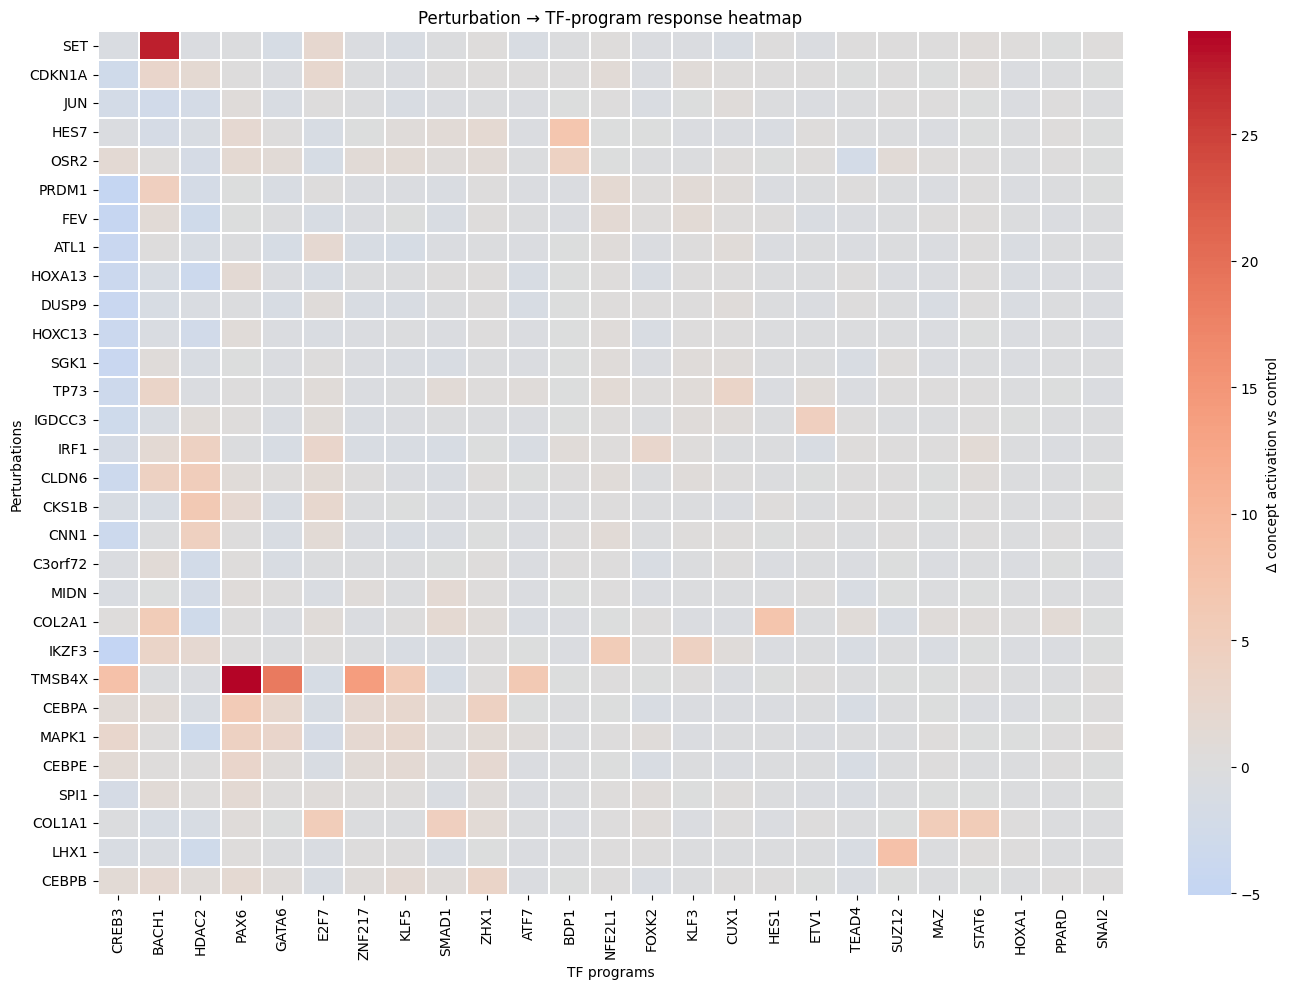

Saved: PERTURBATION_TF_NETWORK_PLOT_ARTIFACTS


In [28]:

# === Cell 26: visualize perturbation -> TF-program response heatmap ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

if "perturbation_tf_network_df" not in globals():
    raise RuntimeError("perturbation_tf_network_df not found. Run Cell 25 first.")

# --------------------------------------------------
# Select top perturbations and top concepts for a readable panel
# --------------------------------------------------
n_perturbations = 30
n_concepts = 25

perturbation_strength = delta_fingerprints_final.abs().sum(axis=1).sort_values(ascending=False)
selected_perturbations = perturbation_strength.head(n_perturbations).index.astype(str).tolist()

concept_strength = (
    perturbation_tf_network_df.groupby("target_concept")["abs_delta"]
    .mean()
    .sort_values(ascending=False)
)
selected_concepts = concept_strength.head(n_concepts).index.astype(str).tolist()

plot_df = delta_fingerprints_final.loc[selected_perturbations, selected_concepts].copy()

# --------------------------------------------------
# Row-wise ordering by dominant concept pattern
# --------------------------------------------------
row_order = (
    plot_df.abs().idxmax(axis=1).astype(str).to_frame("dominant_concept")
    .assign(total_abs=plot_df.abs().sum(axis=1))
    .sort_values(["dominant_concept", "total_abs"], ascending=[True, False])
    .index
)
plot_df = plot_df.loc[row_order]

# --------------------------------------------------
# Column ordering by overall importance
# --------------------------------------------------
col_order = plot_df.abs().sum(axis=0).sort_values(ascending=False).index.astype(str).tolist()
plot_df = plot_df[col_order]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(14, 10))

sns.heatmap(
    plot_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Δ concept activation vs control"}
)

plt.title("Perturbation → TF-program response heatmap")
plt.xlabel("TF programs")
plt.ylabel("Perturbations")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Save
# --------------------------------------------------
PERTURBATION_TF_NETWORK_PLOT_ARTIFACTS = {
    "plot_df": plot_df,
    "selected_perturbations": selected_perturbations,
    "selected_concepts": selected_concepts,
}

print("Saved: PERTURBATION_TF_NETWORK_PLOT_ARTIFACTS")


## Interpretation: response heatmap replaces an unreadable node-link graph

The earlier node-link visualization was too cluttered for paper use. The heatmap introduced here is preferable because it keeps the same information content while making several features visible at once:

- which perturbations have the largest total response magnitude,
- which TF programs recur across many perturbations,
- and whether blocks of perturbations share similar dominant concept profiles.

This is the recommended visualization to keep for figure development.

In [29]:

# === Cell 27: statistical validation of biological coherence in concept-response space ===

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "perturbation_corr_df" not in globals():
    raise RuntimeError("perturbation_corr_df not found. Run Cell 23 first.")

# --------------------------------------------------
# Curated perturbation groups
# Keep this explicit and modest: this is a sanity check,
# not a universal annotation framework.
# --------------------------------------------------
candidate_groups = {
    "CEBP_family": ["CEBPA", "CEBPB", "CEBPE"],
    "CDKN_family": ["CDKN1A", "CDKN1B", "CDKN1C"],
    "Apoptosis_related": ["BAK1", "BCL2L11"],
    "MAPK_signaling": ["DUSP9", "MAP2K3", "ETS2"],
    "PTPN_family": ["PTPN1", "PTPN12"],
}

available_perts = set(perturbation_corr_df.index.astype(str))
group_map = {
    group: [p for p in members if p in available_perts]
    for group, members in candidate_groups.items()
}

# keep groups with at least 2 available perturbations
group_map = {g: members for g, members in group_map.items() if len(members) >= 2}

if len(group_map) == 0:
    raise RuntimeError("No curated groups with at least 2 perturbations are present in perturbation_corr_df.")

# --------------------------------------------------
# Within-group vs between-group similarity
# --------------------------------------------------
rows = []

for group, members in group_map.items():
    other_members = [p for p in perturbation_corr_df.index.astype(str) if p not in members]

    within_vals = []
    for i, p1 in enumerate(members):
        for p2 in members[i+1:]:
            within_vals.append(float(perturbation_corr_df.loc[p1, p2]))

    between_vals = []
    for p1 in members:
        for p2 in other_members:
            between_vals.append(float(perturbation_corr_df.loc[p1, p2]))

    if len(within_vals) == 0 or len(between_vals) == 0:
        continue

    stat, pval = mannwhitneyu(within_vals, between_vals, alternative="greater")

    rows.append({
        "group": group,
        "n_group_members": int(len(members)),
        "members": members,
        "within_mean_corr": float(np.mean(within_vals)),
        "within_median_corr": float(np.median(within_vals)),
        "between_mean_corr": float(np.mean(between_vals)),
        "between_median_corr": float(np.median(between_vals)),
        "delta_mean_corr": float(np.mean(within_vals) - np.mean(between_vals)),
        "mannwhitney_u": float(stat),
        "p_value_greater": float(pval),
    })

biological_coherence_df = pd.DataFrame(rows).sort_values(
    ["delta_mean_corr", "within_mean_corr"], ascending=False
).reset_index(drop=True)

print("Curated biological coherence summary")
display(biological_coherence_df)

# --------------------------------------------------
# Local-neighborhood consistency
# This is broader than the curated groups above.
# --------------------------------------------------
neighbor_rows = []

perturbations = perturbation_corr_df.index.astype(str).tolist()
pert_to_group = {}
for group, members in group_map.items():
    for p in members:
        pert_to_group[p] = group

for pert in perturbations:
    if pert not in pert_to_group:
        continue

    sims = perturbation_corr_df.loc[pert].drop(index=pert).sort_values(ascending=False)
    top5 = sims.head(5).index.astype(str).tolist()

    same_group_hits = sum(1 for nbr in top5 if pert_to_group.get(nbr) == pert_to_group[pert])

    neighbor_rows.append({
        "perturbation": pert,
        "group": pert_to_group[pert],
        "top5_neighbors": top5,
        "same_group_top5_hits": int(same_group_hits),
        "same_group_top5_fraction": float(same_group_hits / 5.0),
    })

neighbor_consistency_df = pd.DataFrame(neighbor_rows)

if len(neighbor_consistency_df) > 0:
    neighbor_group_summary_df = (
        neighbor_consistency_df
        .groupby("group")
        .agg(
            n_perturbations=("perturbation", "count"),
            mean_same_group_top5_fraction=("same_group_top5_fraction", "mean"),
            median_same_group_top5_fraction=("same_group_top5_fraction", "median"),
        )
        .reset_index()
        .sort_values("mean_same_group_top5_fraction", ascending=False)
        .reset_index(drop=True)
    )
else:
    neighbor_group_summary_df = pd.DataFrame()

print("\nLocal neighborhood consistency")
display(neighbor_consistency_df)

print("\nNeighborhood consistency by group")
display(neighbor_group_summary_df)

# --------------------------------------------------
# Save
# --------------------------------------------------
BIOLOGICAL_COHERENCE_ARTIFACTS = {
    "group_map": group_map,
    "biological_coherence_df": biological_coherence_df,
    "neighbor_consistency_df": neighbor_consistency_df,
    "neighbor_group_summary_df": neighbor_group_summary_df,
}

print("Saved: BIOLOGICAL_COHERENCE_ARTIFACTS")


Curated biological coherence summary


,group,n_group_members,members,within_mean_corr,within_median_corr,between_mean_corr,between_median_corr,delta_mean_corr,mannwhitney_u,p_value_greater
0,CEBP_family,3,"[CEBPA, CEBPB, CEBPE]",0.881702,0.898217,0.138840,0.142994,0.742862,917.0,4.107085e-07
1,CDKN_family,3,"[CDKN1A, CDKN1B, CDKN1C]",0.758097,0.759114,0.273729,0.309176,0.484368,913.0,3.285668e-06
2,PTPN_family,2,"[PTPN1, PTPN12]",0.759909,0.759909,0.284536,0.337178,0.475372,196.0,5.314010e-02
3,Apoptosis_related,2,"[BAK1, BCL2L11]",0.239847,0.239847,-0.021609,-0.042259,0.261456,180.0,1.304348e-01
4,MAPK_signaling,3,"[DUSP9, MAP2K3, ETS2]",-0.329062,-0.367989,0.038818,0.000750,-0.367880,178.0,9.664585e-01



Local neighborhood consistency


,perturbation,group,top5_neighbors,same_group_top5_hits,same_group_top5_fraction
0,BCL2L11,Apoptosis_related,"[ELMSAN1, CNN1, CLDN6, MAP2K3, SLC6A9]",0,0.0
1,BAK1,Apoptosis_related,"[MAP2K3, ELMSAN1, IRF1, MAP2K6, MAML2]",0,0.0
2,MAP2K3,MAPK_signaling,"[ELMSAN1, MAP2K6, CSRNP1, BAK1, KLF1]",0,0.0
3,DUSP9,MAPK_signaling,"[ATL1, C19orf26, SAMD1, RHOXF2, IER5L]",0,0.0
4,CDKN1A,CDKN_family,"[CDKN1B, CLDN6, CDKN1C, CBL, ZBTB25]",2,0.4
5,CDKN1B,CDKN_family,"[CDKN1C, CLDN6, CDKN1A, CBL, ZBTB25]",2,0.4
6,CDKN1C,CDKN_family,"[CDKN1B, CDKN1A, IER5L, CLDN6, CBL]",2,0.4
7,PTPN1,PTPN_family,"[PTPN9, UBASH3B, ZBTB25, CBL, SAMD1]",0,0.0
8,PTPN12,PTPN_family,"[CLDN6, CBL, UBASH3B, ZBTB25, CNN1]",0,0.0
9,CEBPB,CEBP_family,"[CEBPE, FOSB, CEBPA, CELF2, MAPK1]",2,0.4



Neighborhood consistency by group


,group,n_perturbations,mean_same_group_top5_fraction,median_same_group_top5_fraction
0,CDKN_family,3,0.4,0.4
1,CEBP_family,3,0.4,0.4
2,Apoptosis_related,2,0.0,0.0
3,MAPK_signaling,3,0.0,0.0
4,PTPN_family,2,0.0,0.0


Saved: BIOLOGICAL_COHERENCE_ARTIFACTS


## Interpretation: statistical validation of biological coherence

This cell provides a more formal  that local structure in concept space is biologically meaningful.

There are two layers:

1. **Curated group tests** compare within-group vs between-group similarity for hand-specified families such as CEBP and CDKN.
2. **Neighborhood consistency** s whether the nearest neighbors of a perturbation tend to belong to the same curated group.

These are modest but important sanity s. They do not prove mechanism by themselves, but they do show that the geometry is not arbitrary.

In [30]:

# === Cell 28: reconstruct directed TF -> TF influence graph ===

import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

if "concept_names" not in globals():
    raise RuntimeError("concept_names not found")

# --------------------------------------------------
# Build directed TF -> TF influence graph
# Source TF = perturbation name, if present in concept space
# Target TF = shifted concept
# --------------------------------------------------
df = delta_fingerprints_final.copy()
concept_set = set([str(c) for c in concept_names])

top_k = 5
edge_rows = []

for perturbation, row in df.iterrows():
    source_tf = str(perturbation)

    # only perturbations that are also represented as concepts
    if source_tf not in concept_set:
        continue

    row = row.astype(float)

    # remove self-edge from ranking, then recover separately if needed
    candidate_row = row.drop(labels=[source_tf], errors="ignore")

    if candidate_row.empty:
        continue

    top_targets = candidate_row.abs().sort_values(ascending=False).head(top_k)

    for rank, (target_tf, abs_val) in enumerate(top_targets.items(), start=1):
        signed_val = float(row.loc[target_tf])

        edge_rows.append({
            "source_tf": source_tf,
            "target_tf": str(target_tf),
            "rank": int(rank),
            "abs_influence": float(abs_val),
            "signed_influence": signed_val,
            "direction": "activation" if signed_val > 0 else "repression",
        })

tf_influence_edges_df = pd.DataFrame(edge_rows)

if tf_influence_edges_df.empty:
    raise RuntimeError("No TF -> TF edges could be constructed from the current perturbation/concept overlap.")

# --------------------------------------------------
# Self-response table
# --------------------------------------------------
self_rows = []

for perturbation, row in df.iterrows():
    source_tf = str(perturbation)
    if source_tf not in concept_set:
        continue

    self_val = float(row.loc[source_tf]) if source_tf in row.index else np.nan

    self_rows.append({
        "source_tf": source_tf,
        "self_response": self_val,
        "self_abs_response": float(abs(self_val)) if pd.notna(self_val) else np.nan,
    })

tf_self_response_df = pd.DataFrame(self_rows).sort_values(
    "self_abs_response", ascending=False
).reset_index(drop=True)

# --------------------------------------------------
# Node summaries
# --------------------------------------------------
out_degree_summary_df = (
    tf_influence_edges_df.groupby("source_tf")
    .agg(
        n_targets=("target_tf", "nunique"),
        mean_abs_influence=("abs_influence", "mean"),
        max_abs_influence=("abs_influence", "max"),
    )
    .reset_index()
    .sort_values("mean_abs_influence", ascending=False)
    .reset_index(drop=True)
)

in_degree_summary_df = (
    tf_influence_edges_df.groupby("target_tf")
    .agg(
        n_sources=("source_tf", "nunique"),
        mean_abs_influence=("abs_influence", "mean"),
        max_abs_influence=("abs_influence", "max"),
    )
    .reset_index()
    .sort_values("mean_abs_influence", ascending=False)
    .reset_index(drop=True)
)

print("tf_influence_edges_df shape:", tf_influence_edges_df.shape)
display(tf_influence_edges_df.head(25))

print("\ntf_self_response_df shape:", tf_self_response_df.shape)
display(tf_self_response_df.head(20))

print("\nout_degree_summary_df shape:", out_degree_summary_df.shape)
display(out_degree_summary_df.head(20))

print("\nin_degree_summary_df shape:", in_degree_summary_df.shape)
display(in_degree_summary_df.head(20))

# --------------------------------------------------
# Wide adjacency matrix
# --------------------------------------------------
tf_influence_matrix_df = (
    tf_influence_edges_df.pivot_table(
        index="source_tf",
        columns="target_tf",
        values="signed_influence",
        aggfunc="first",
        fill_value=0.0,
    )
    .sort_index(axis=0)
    .sort_index(axis=1)
)

print("\ntf_influence_matrix_df shape:", tf_influence_matrix_df.shape)
display(tf_influence_matrix_df.iloc[:10, :10])

# --------------------------------------------------
# Save
# --------------------------------------------------
TF_INFLUENCE_GRAPH_ARTIFACTS = {
    "tf_influence_edges_df": tf_influence_edges_df,
    "tf_self_response_df": tf_self_response_df,
    "out_degree_summary_df": out_degree_summary_df,
    "in_degree_summary_df": in_degree_summary_df,
    "tf_influence_matrix_df": tf_influence_matrix_df,
    "top_k": top_k,
}

print("Saved: TF_INFLUENCE_GRAPH_ARTIFACTS")


tf_influence_edges_df shape: (70, 6)


,source_tf,target_tf,rank,abs_influence,signed_influence,direction
0,AHR,CREB3,1,2.557978,-2.557978,repression
1,AHR,BRCA1,2,1.839481,-1.839481,repression
2,AHR,HDAC2,3,1.693273,-1.693273,repression
3,AHR,MBD2,4,1.515983,-1.515983,repression
4,AHR,THAP1,5,1.462721,-1.462721,repression
5,CEBPE,PAX6,1,2.874707,2.874707,activation
6,CEBPE,MBD2,2,2.059470,-2.059470,repression
7,CEBPE,ZHX1,3,2.027251,2.027251,activation
8,CEBPE,CDX2,4,1.708142,-1.708142,repression
9,CEBPE,LMO2,5,1.651701,-1.651701,repression



tf_self_response_df shape: (14, 3)


,source_tf,self_response,self_abs_response
0,ETS2,-0.184588,0.184588
1,FOXO4,-0.089615,0.089615
2,MEIS1,-0.083152,0.083152
3,AHR,0.044783,0.044783
4,FOXL2,0.016227,0.016227
5,SNAI1,0.015699,0.015699
6,POU3F2,-0.005621,0.005621
7,CEBPE,0.000000,0.000000
8,KLF1,0.000000,0.000000
9,KMT2A,0.000000,0.000000



out_degree_summary_df shape: (14, 4)


...


in_degree_summary_df shape: (26, 4)


,target_tf,n_sources,mean_abs_influence,max_abs_influence
0,HOXA1,1,6.207302,6.207302
1,CUX1,1,3.357096,3.357096
2,CREB3,8,2.742707,4.880527
3,PAX6,2,2.430261,2.874707
4,NEUROD1,1,2.054085,2.054085
5,NR1H2,2,2.050031,2.928069
6,BACH1,6,2.045461,4.564185
7,ZHX1,1,2.027251,2.027251
8,GATA6,1,2.016905,2.016905
9,MBD2,7,1.993138,4.995579



tf_influence_matrix_df shape: (14, 26)


target_tf,ARID2,ATF4,BACH1,BACH2,BRCA1,BRF2,CDX2,CREB3,CREM,CUX1
source_tf,,,,,,,,,,
AHR,0.000000,0.0,0.000000,0.0,-1.839481,0.0,0.000000,-2.557978,0.000000,0.0
CEBPE,0.000000,0.0,0.000000,0.0,0.000000,0.0,-1.708142,0.000000,0.000000,0.0
ETS2,0.000000,0.0,0.000000,0.0,0.000000,0.0,-1.959901,2.433795,0.000000,0.0
FOXL2,-1.866049,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0
FOXO4,-1.313679,0.0,0.000000,0.0,-1.670292,0.0,0.000000,0.000000,-1.164132,0.0
KLF1,0.000000,0.0,1.598940,0.0,2.920918,0.0,0.000000,-3.846428,0.000000,0.0
KMT2A,0.000000,0.0,-1.099734,0.0,0.000000,0.0,-1.369098,0.000000,0.000000,0.0
LYL1,0.000000,0.0,-1.058625,0.0,0.000000,0.0,0.000000,0.000000,-1.554143,0.0
MEIS1,0.000000,0.0,-0.757294,0.0,-1.030410,0.0,0.000000,-1.495439,0.000000,0.0


Saved: TF_INFLUENCE_GRAPH_ARTIFACTS


## Interpretation: directed TF → TF influence graph

This reconstruction focuses on perturbations whose names also exist in the TF concept library and asks how they project onto other TF programs. Two outputs matter:

- **`tf_self_response_df`** quantifies the self-axis response.
- **`tf_influence_edges_df`** records the strongest non-self outgoing influences.

Low self-response does not have a single interpretation. It can reflect true downstream redistribution, incomplete concept coverage, or weak concept identifiability. This is why the final notebook interpretation combines self-response with selectivity and driver overlap rather than relying on self-match alone.

In [31]:

# === Cell 29: identify dominant TF-program axes ===

import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "perturbation_embedding_df" not in globals():
    raise RuntimeError("perturbation_embedding_df not found. Run Cell 24 first.")

if "pc_loading_df" not in globals():
    raise RuntimeError("pc_loading_df not found. Run Cell 24 first.")

if "explained_variance_df" not in globals():
    raise RuntimeError("explained_variance_df not found. Run Cell 24 first.")

# --------------------------------------------------
# Dominant axes summary from PCA loadings
# --------------------------------------------------
n_axes = min(5, explained_variance_df.shape[0])

axis_rows = []

for pc_idx in range(1, n_axes + 1):
    pc_name = f"PC{pc_idx}"

    pc_info = explained_variance_df.loc[
        explained_variance_df["PC"] == pc_name
    ]
    if len(pc_info) != 1:
        raise RuntimeError(f"Could not find explained variance info for {pc_name}")

    pc_info = pc_info.iloc[0]

    pc_loadings = pc_loading_df.loc[
        (pc_loading_df["PC"] == pc_name) &
        (pc_loading_df["ranking"] == "absolute")
    ].sort_values("rank")

    if pc_loadings.empty:
        continue

    top_concepts = pc_loadings["concept"].astype(str).tolist()
    top_abs_loadings = pc_loadings["abs_loading"].astype(float).tolist()

    signed_loadings_df = (
        pc_loading_df.loc[
            (pc_loading_df["PC"] == pc_name) &
            (pc_loading_df["ranking"] == "signed")
        ]
        .copy()
        .sort_values(["direction", "rank"])
    )

    top_positive = (
        signed_loadings_df.loc[signed_loadings_df["direction"] == "positive"]
        .sort_values("rank")
        .head(5)["concept"]
        .astype(str)
        .tolist()
    )

    top_negative = (
        signed_loadings_df.loc[signed_loadings_df["direction"] == "negative"]
        .sort_values("rank")
        .head(5)["concept"]
        .astype(str)
        .tolist()
    )

    axis_rows.append({
        "PC": pc_name,
        "explained_variance_ratio": float(pc_info["explained_variance_ratio"]),
        "cumulative_explained_variance": float(pc_info["cumulative_explained_variance"]),
        "top_absolute_concepts": top_concepts[:10],
        "top_absolute_loadings": top_abs_loadings[:10],
        "top_positive_concepts": top_positive,
        "top_negative_concepts": top_negative,
    })

dominant_tf_axes_df = pd.DataFrame(axis_rows)

print("dominant_tf_axes_df shape:", dominant_tf_axes_df.shape)
display(dominant_tf_axes_df)

# --------------------------------------------------
# Leading perturbations on each axis
# --------------------------------------------------
embedding_cols = [c for c in perturbation_embedding_df.columns if c.startswith("PC")]

leading_rows = []

for pc_name in embedding_cols[:n_axes]:
    pc_scores = (
        perturbation_embedding_df[["perturbation", pc_name]]
        .copy()
        .rename(columns={pc_name: "score"})
    )

    top_positive = pc_scores.sort_values("score", ascending=False).head(10)
    top_negative = pc_scores.sort_values("score", ascending=True).head(10)
    top_absolute = pc_scores.assign(abs_score=pc_scores["score"].abs()).sort_values(
        "abs_score", ascending=False
    ).head(10)

    for rank, row in enumerate(top_positive.itertuples(index=False), start=1):
        leading_rows.append({
            "PC": pc_name,
            "direction": "positive",
            "rank": rank,
            "perturbation": str(row.perturbation),
            "score": float(row.score),
            "abs_score": float(abs(row.score)),
        })

    for rank, row in enumerate(top_negative.itertuples(index=False), start=1):
        leading_rows.append({
            "PC": pc_name,
            "direction": "negative",
            "rank": rank,
            "perturbation": str(row.perturbation),
            "score": float(row.score),
            "abs_score": float(abs(row.score)),
        })

    for rank, row in enumerate(top_absolute.itertuples(index=False), start=1):
        leading_rows.append({
            "PC": pc_name,
            "direction": "absolute",
            "rank": rank,
            "perturbation": str(row.perturbation),
            "score": float(row.score),
            "abs_score": float(row.abs_score),
        })

dominant_axis_perturbations_df = pd.DataFrame(leading_rows)

print("\ndominant_axis_perturbations_df shape:", dominant_axis_perturbations_df.shape)
display(dominant_axis_perturbations_df.head(40))

# --------------------------------------------------
# Compact wide summary
# --------------------------------------------------
dominant_axis_summary_wide_df = (
    dominant_axis_perturbations_df.loc[
        dominant_axis_perturbations_df["direction"] == "absolute"
    ]
    .pivot(index="PC", columns="rank", values="perturbation")
    .rename(columns={i: f"top_perturbation_{i}" for i in sorted(dominant_axis_perturbations_df["rank"].unique())})
    .reset_index()
)

print("\ndominant_axis_summary_wide_df shape:", dominant_axis_summary_wide_df.shape)
display(dominant_axis_summary_wide_df)

# --------------------------------------------------
# Save
# --------------------------------------------------
DOMINANT_TF_AXES_ARTIFACTS = {
    "dominant_tf_axes_df": dominant_tf_axes_df,
    "dominant_axis_perturbations_df": dominant_axis_perturbations_df,
    "dominant_axis_summary_wide_df": dominant_axis_summary_wide_df,
}

print("Saved: DOMINANT_TF_AXES_ARTIFACTS")


dominant_tf_axes_df shape: (5, 7)


,PC,explained_variance_ratio,cumulative_explained_variance,top_absolute_concepts,top_absolute_loadings,top_positive_concepts,top_negative_concepts
0,PC1,0.304443,0.304443,"[PAX6, GATA6, ZNF217, CREB3, KLF5, ZNF83, ATF7...","[0.6328639984130859, 0.43686914443969727, 0.32...","[PAX6, GATA6, ZNF217, CREB3, KLF5]","[CDX2, E2F7, NR1H2, BACH1, HDAC2]"
1,PC2,0.157288,0.461731,"[BACH1, HDAC2, ARID2, BRCA1, E2F7, BRF2, CREB3...","[0.9178012609481812, 0.16390575468540192, 0.09...","[BACH1, HDAC2, ARID2, BRCA1, E2F7]","[NEUROD1, CCNT2, CUX1, PTTG1, BDP1]"
2,PC3,0.110912,0.572643,"[HDAC2, BACH1, BRCA1, MBD2, THAP1, CDX2, ZC3H8...","[0.5357210636138916, 0.3141641318798065, 0.252...","[HDAC2, BRCA1, MBD2, THAP1, CDX2]","[BACH1, ZNF589, ZHX1, PTTG1, SMAD1]"
3,PC4,0.100188,0.672831,"[CREB3, PAX6, NR1H2, ARID2, BACH2, GTF2F1, BRC...","[0.3830051124095917, 0.3710644543170929, 0.281...","[CREB3, ARID2, BACH2, GTF2F1, BRCA1]","[PAX6, NR1H2, NEUROD1, NFE2L1, LMO2]"
4,PC5,0.039037,0.711868,"[HDAC2, ARID2, E2F7, NR1H2, CREB3, LMO2, ZHX1,...","[0.48632052540779114, 0.27715766429901123, 0.2...","[HDAC2, E2F7, CREB3, ZHX1, SMAD1]","[ARID2, NR1H2, LMO2, BRCA1, DEAF1]"



dominant_axis_perturbations_df shape: (150, 6)


,PC,direction,rank,perturbation,score,abs_score
0,PC1,positive,1,TMSB4X,38.616821,38.616821
1,PC1,positive,2,MAPK1,8.359602,8.359602
2,PC1,positive,3,CEBPA,8.287742,8.287742
3,PC1,positive,4,ETS2,5.386437,5.386437
4,PC1,positive,5,CEBPE,4.534414,4.534414
5,PC1,positive,6,OSR2,4.325886,4.325886
6,PC1,positive,7,CEBPB,3.239319,3.239319
7,PC1,positive,8,HES7,2.471792,2.471792
8,PC1,positive,9,CELF2,2.387812,2.387812
9,PC1,positive,10,FOSB,2.051021,2.051021



dominant_axis_summary_wide_df shape: (5, 11)


rank,PC,top_perturbation_1,top_perturbation_2,top_perturbation_3,top_perturbation_4,top_perturbation_5,top_perturbation_6,top_perturbation_7,top_perturbation_8,top_perturbation_9,top_perturbation_10
0,PC1,TMSB4X,MAPK1,CEBPA,ETS2,CEBPE,SET,OSR2,ATL1,IKZF3,DUSP9
1,PC2,SET,COL2A1,MAP2K3,HOXA13,CLDN6,HES7,JUN,HOXC13,TMSB4X,IRF1
2,PC3,SET,ELMSAN1,CNN1,IRF1,HES7,HOXA13,CKS1B,CEBPA,KLF1,COL2A1
3,PC4,TMSB4X,IKZF3,PRDM1,ATL1,CLDN6,MAP2K6,OSR2,FOSB,MAP2K3,SLC38A2
4,PC5,CKS1B,COL1A1,HNF4A,FEV,HES7,IRF1,CEBPA,CEBPB,SLC4A1,CEBPE


Saved: DOMINANT_TF_AXES_ARTIFACTS


## Interpretation: dominant TF-program axes

The dominant-axis summary is the highest-level systems view in the notebook. It identifies the main regulatory directions in the perturbation manifold and the perturbations that anchor them.

At this stage the Norman analysis already supports a strong claim: **the bottleneck learns structured perturbation geometry**. What it does **not** yet establish is whether those axes correspond to mechanistically grounded downstream gene programs. That is the purpose of the final section.

# VI. Gene-level mechanistic validation

The final block adds the missing ingredient that distinguishes structured geometry from mechanistic interpretability: gene-level driver attribution and overlap with curated expected downstream targets.

In [32]:

# === Cell 30: compute gene-level drivers from model gradients ===

import torch
import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
required = ["model", "test_loader"]
for r in required:
    if r not in globals():
        raise RuntimeError(f"{r} not found")

# --------------------------------------------------
# Resolve gene names
# --------------------------------------------------
if "gene_universe" in globals():
    gene_names = [str(g) for g in gene_universe]
elif "adata_bench" in globals():
    gene_names = [str(g) for g in adata_bench.var_names]
else:
    raise RuntimeError("Could not resolve gene names from gene_universe or adata_bench.var_names")

device = next(model.parameters()).device

# --------------------------------------------------
# Compute gradients wrt input genes
# --------------------------------------------------
model.eval()

all_gene_attr = []
all_labels = []

for xb, yb in test_loader:
    xb = xb.to(device)
    xb.requires_grad_(True)

    model.zero_grad(set_to_none=True)
    logits, concept_acts = model(xb)

    preds = logits.argmax(dim=1)
    selected_logits = logits[torch.arange(xb.size(0), device=device), preds]
    selected_logits.sum().backward()

    grads = xb.grad.detach().cpu().numpy()

    all_gene_attr.append(grads)
    all_labels.append(yb.detach().cpu().numpy())

gene_attr = np.vstack(all_gene_attr)
labels = np.concatenate(all_labels)

# --------------------------------------------------
# Build dataframe
# --------------------------------------------------
gene_attr_df = pd.DataFrame(gene_attr, columns=gene_names)
gene_attr_df["label_idx"] = labels

if "idx_to_label" not in globals():
    raise RuntimeError("idx_to_label not found")

gene_attr_df["perturbation"] = gene_attr_df["label_idx"].map(idx_to_label)

# --------------------------------------------------
# Average per perturbation
# --------------------------------------------------
mean_gene_attr_df = (
    gene_attr_df.groupby("perturbation")[gene_names]
    .mean()
)

print("mean_gene_attr_df shape:", mean_gene_attr_df.shape)
display(mean_gene_attr_df.head())

# --------------------------------------------------
# Extract top-k drivers
# --------------------------------------------------
top_k = 50
rows = []

for pert, row in mean_gene_attr_df.iterrows():
    top_genes = row.abs().sort_values(ascending=False).head(top_k)

    for rank, (gene, val) in enumerate(top_genes.items(), start=1):
        rows.append({
            "perturbation": str(pert),
            "rank": int(rank),
            "gene": str(gene),
            "abs_attr": float(abs(val)),
            "signed_attr": float(val),
        })

top_driver_genes_df = pd.DataFrame(rows)

print("\ntop_driver_genes_df shape:", top_driver_genes_df.shape)
display(top_driver_genes_df.head(20))

# --------------------------------------------------
# Save
# --------------------------------------------------
GENE_ATTRIBUTION_ARTIFACTS = {
    "gene_names": gene_names,
    "mean_gene_attr_df": mean_gene_attr_df,
    "top_driver_genes_df": top_driver_genes_df,
    "top_k": top_k,
}

print("Saved: GENE_ATTRIBUTION_ARTIFACTS")


mean_gene_attr_df shape: (106, 33684)


,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,bP-21264C1.2,bP-2171C21.3,bP-2189O9.3,hsa-mir-1253
perturbation,,,,,,,,,,,,,,,,,,,,,
AHR,0.0,0.0,0.007703,0.000661,0.0,-0.008927,0.0,0.0,0.0,0.000764,...,0.0,0.004067,0.0,0.000584,-0.005057,-0.007813,0.0,0.0,0.0,0.0
ARID1A,0.0,0.0,0.003054,0.000400,0.0,0.000008,0.0,0.0,0.0,0.005726,...,0.0,0.004684,0.0,-0.000356,0.000021,-0.003814,0.0,0.0,0.0,0.0
ARRDC3,0.0,0.0,-0.001525,0.001258,0.0,0.000984,0.0,0.0,0.0,0.001434,...,0.0,0.001951,0.0,0.000500,-0.000573,-0.002104,0.0,0.0,0.0,0.0
ATL1,0.0,0.0,-0.004149,0.001566,0.0,-0.000523,0.0,0.0,0.0,0.010983,...,0.0,0.001706,0.0,-0.000472,0.006430,0.000448,0.0,0.0,0.0,0.0
BAK1,0.0,0.0,-0.001388,0.000925,0.0,-0.001815,0.0,0.0,0.0,0.000264,...,0.0,0.001880,0.0,0.000371,0.000931,-0.001813,0.0,0.0,0.0,0.0



top_driver_genes_df shape: (5300, 5)


,perturbation,rank,gene,abs_attr,signed_attr
0,AHR,1,RGS6,0.558415,0.558415
1,AHR,2,AHR,0.416514,0.416514
2,AHR,3,NFASC,0.235136,0.235136
3,AHR,4,CTTNBP2,0.232563,0.232563
4,AHR,5,POU3F2,0.223193,0.223193
5,AHR,6,LIFR,0.218116,0.218116
6,AHR,7,RUNX1T1,0.206307,0.206307
7,AHR,8,ACOXL,0.197415,0.197415
8,AHR,9,BHLHE40,0.187518,0.187518
9,AHR,10,EGLN3,0.149772,0.149772


Saved: GENE_ATTRIBUTION_ARTIFACTS


## Interpretation: gradient-based driver extraction

This cell derives perturbation-level driver genes directly from input gradients. The output is intentionally simple:

- a perturbation-by-gene attribution matrix,
- plus the top `50` attributed genes for each perturbation.

This is the main gene-level object used for the mechanistic s below. Without this block, the notebook would remain purely geometric.

In [34]:

# === Cell 31: define expected driver genes for selected perturbations ===

import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "top_driver_genes_df" not in globals():
    raise RuntimeError("top_driver_genes_df not found. Run Cell 30 first.")

# --------------------------------------------------
# Minimal curated expectations (focused, not exhaustive)
# These are biologically plausible downstream responses
# --------------------------------------------------
EXPECTED_DRIVER_MAP = {
    # Cell cycle / proliferation
    "MYBL2": ["MKI67", "TOP2A", "PCNA", "CDK1"],
    "E2F1": ["MCM2", "MCM3", "MCM5", "PCNA"],
    "CDKN1A": ["CDKN1A", "GADD45A", "BTG2"],

    # Apoptosis / stress
    "BAK1": ["BAX", "BBC3", "CASP3", "CASP7"],
    "BCL2L11": ["BCL2L11", "BBC3", "PMAIP1"],

    # Myeloid / differentiation
    "CEBPA": ["CEBPA", "CEBPB", "CEBPE", "SPI1"],
    "CEBPB": ["CEBPA", "CEBPB", "IL6", "TNF"],

    # p53 pathway
    "TP53": ["CDKN1A", "MDM2", "GADD45A", "BAX"],

    # MAPK / signaling
    "DUSP9": ["DUSP1", "DUSP6", "FOS", "JUN"],

    # circadian / transcriptional
    "CLOCK": ["PER1", "PER2", "CRY1", "ARNTL"],
}

# --------------------------------------------------
# Filter to perturbations present in dataset
# --------------------------------------------------
available_perts = set(top_driver_genes_df["perturbation"].astype(str))

filtered_map = {
    pert: genes
    for pert, genes in EXPECTED_DRIVER_MAP.items()
    if pert in available_perts
}

if len(filtered_map) == 0:
    print("Warning: no curated perturbations found in dataset")

# --------------------------------------------------
# Convert to DataFrame
# --------------------------------------------------
rows = []

for pert, genes in filtered_map.items():
    for g in genes:
        rows.append({
            "perturbation": str(pert),
            "expected_gene": str(g),
        })

expected_driver_df = pd.DataFrame(rows)

print("expected_driver_df shape:", expected_driver_df.shape)
display(expected_driver_df.head(20))

# --------------------------------------------------
# Save
# --------------------------------------------------
EXPECTED_DRIVER_ARTIFACTS = {
    "expected_driver_df": expected_driver_df,
    "expected_driver_map": filtered_map,
}

print("Saved: EXPECTED_DRIVER_ARTIFACTS")


expected_driver_df shape: (22, 2)


,perturbation,expected_gene
0,CDKN1A,CDKN1A
1,CDKN1A,GADD45A
2,CDKN1A,BTG2
3,BAK1,BAX
4,BAK1,BBC3
5,BAK1,CASP3
6,BAK1,CASP7
7,BCL2L11,BCL2L11
8,BCL2L11,BBC3
9,BCL2L11,PMAIP1


Saved: EXPECTED_DRIVER_ARTIFACTS


## Interpretation: curated expected drivers

The expectation table is deliberately small and focused. It is not meant to exhaust all plausible downstream biology in Norman. Instead, it provides a compact set of benchmark perturbations where a reader can evaluate whether the concept-space response is also accompanied by recognizable gene-level recovery.

The selected perturbations span:
- cell-cycle / growth control (`CDKN1A`, `MYBL2`, `E2F1`),
- differentiation (`CEBPA`, `CEBPB`),
- stress / apoptosis (`BAK1`, `BCL2L11`),
- signaling (`DUSP9`),
- and a small circadian example (`CLOCK`).

In [35]:

# === Cell 32: compute overlap between attributed drivers and expected drivers ===

import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "top_driver_genes_df" not in globals():
    raise RuntimeError("top_driver_genes_df not found. Run Cell 30 first.")

if "expected_driver_df" not in globals():
    raise RuntimeError("expected_driver_df not found. Run Cell 31 first.")

# --------------------------------------------------
# Restrict to perturbations with expectations
# --------------------------------------------------
available_expected_perts = expected_driver_df["perturbation"].astype(str).unique().tolist()

filtered_top_driver_genes_df = (
    top_driver_genes_df.loc[
        top_driver_genes_df["perturbation"].astype(str).isin(available_expected_perts)
    ]
    .copy()
)

if filtered_top_driver_genes_df.empty:
    raise RuntimeError("No overlap between attributed perturbations and expected-driver perturbations.")

# --------------------------------------------------
# Compute overlap summary
# --------------------------------------------------
rows = []

for pert in sorted(available_expected_perts):
    observed = (
        filtered_top_driver_genes_df.loc[
            filtered_top_driver_genes_df["perturbation"].astype(str) == pert, "gene"
        ]
        .astype(str)
        .tolist()
    )

    expected = (
        expected_driver_df.loc[
            expected_driver_df["perturbation"].astype(str) == pert, "expected_gene"
        ]
        .astype(str)
        .tolist()
    )

    observed_set = set(observed)
    expected_set = set(expected)
    overlap = sorted(observed_set.intersection(expected_set))

    rows.append({
        "perturbation": str(pert),
        "n_expected_genes": int(len(expected_set)),
        "n_observed_top_genes": int(len(observed_set)),
        "n_overlap": int(len(overlap)),
        "overlap_fraction_expected": float(len(overlap) / len(expected_set)) if len(expected_set) > 0 else 0.0,
        "overlap_fraction_observed": float(len(overlap) / len(observed_set)) if len(observed_set) > 0 else 0.0,
        "expected_genes": sorted(expected_set),
        "observed_top_genes": observed,
        "overlap_genes": overlap,
    })

driver_overlap_df = pd.DataFrame(rows).sort_values(
    ["overlap_fraction_expected", "n_overlap"],
    ascending=[False, False]
).reset_index(drop=True)

print("driver_overlap_df shape:", driver_overlap_df.shape)
display(driver_overlap_df)

# --------------------------------------------------
# Save
# --------------------------------------------------
DRIVER_OVERLAP_ARTIFACTS = {
    "filtered_top_driver_genes_df": filtered_top_driver_genes_df,
    "driver_overlap_df": driver_overlap_df,
}

print("Saved: DRIVER_OVERLAP_ARTIFACTS")


driver_overlap_df shape: (6, 9)


,perturbation,n_expected_genes,n_observed_top_genes,n_overlap,overlap_fraction_expected,overlap_fraction_observed,expected_genes,observed_top_genes,overlap_genes
0,CDKN1A,3,50,1,0.333333,0.02,"[BTG2, CDKN1A, GADD45A]","[CDKN1A, RUNX1T1, JUN, TNFSF10, CEBPA, CCND1, ...",[CDKN1A]
1,CEBPA,4,50,1,0.250000,0.02,"[CEBPA, CEBPB, CEBPE, SPI1]","[CDKN1A, UTRN, LIFR, SMAD3, NFASC, CEBPA, RUNX...",[CEBPA]
2,CEBPB,4,50,1,0.250000,0.02,"[CEBPA, CEBPB, IL6, TNF]","[RUNX1T1, FOXA1, SMAD3, ALCAM, ARHGAP26, FOXF1...",[CEBPA]
3,BAK1,4,50,0,0.000000,0.00,"[BAX, BBC3, CASP3, CASP7]","[CDKN1A, ID2, POU3F2, MTSS1, PRTG, LGALS3BP, I...",[]
4,BCL2L11,3,50,0,0.000000,0.00,"[BBC3, BCL2L11, PMAIP1]","[FOXF1, POU3F2, MTSS1, ID2, CDKN1A, ARHGAP26, ...",[]
5,DUSP9,4,50,0,0.000000,0.00,"[DUSP1, DUSP6, FOS, JUN]","[KCNN3, FOXA1, NAV2, CDKN1A, CDC42EP4, IGDCC3,...",[]


Saved: DRIVER_OVERLAP_ARTIFACTS


## Interpretation: driver overlap is weak and highly uneven

The overlap table generated in the current run has **6 evaluated perturbations** and reveals a clear limitation:

- `CDKN1A`: `1/3` expected genes recovered (`CDKN1A`)
- `CEBPA`: `1/4` expected genes recovered (`CEBPA`)
- `CEBPB`: `1/4` expected genes recovered, but the overlapping gene is `CEBPA`, not `CEBPB`
- `BAK1`: `0/4`
- `BCL2L11`: `0/3`
- `DUSP9`: `0/4`

Observed-overlap fractions are only **0.02** for the three partial successes and **0.00** for the rest because the top-driver list contains `50` genes.

This result is the decisive contrast with PBMC. Norman clearly preserves perturbation structure, but canonical downstream driver recovery is weak.

In [36]:

# === Cell 33: mechanistic evaluation table (Norman) ===

import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
if "driver_overlap_df" not in globals():
    raise RuntimeError("driver_overlap_df not found. Run Cell 32 first.")

if "delta_fingerprints_final" not in globals():
    raise RuntimeError("delta_fingerprints_final not found. Run Cell 18 first.")

# --------------------------------------------------
# Perturbation-level concept selectivity
# Definition:
#   max concept shift - mean of remaining concept shifts
# --------------------------------------------------
selectivity_rows = []

for pert, row in delta_fingerprints_final.iterrows():
    values = row.astype(float).values
    max_val = float(values.max())

    if len(values) <= 1:
        mean_others = 0.0
    else:
        max_idx = values.argmax()
        mean_others = float(values[np.arange(len(values)) != max_idx].mean())

    selectivity_rows.append({
        "perturbation": str(pert),
        "concept_selectivity": float(max_val - mean_others),
        "max_concept_shift": max_val,
        "mean_other_concept_shift": mean_others,
    })

pert_selectivity_df = pd.DataFrame(selectivity_rows)

# --------------------------------------------------
# Merge overlap + selectivity
# --------------------------------------------------
norman_mech_df = driver_overlap_df.merge(
    pert_selectivity_df,
    on="perturbation",
    how="left"
)

# --------------------------------------------------
# Stricter mechanistic verdict
# Norman should not be labeled "strong" with only 1-gene overlap
# --------------------------------------------------
def classify_mechanistic(row):
    sel = float(row["concept_selectivity"])
    overlap_exp = float(row["overlap_fraction_expected"])
    overlap_obs = float(row["overlap_fraction_observed"])
    n_overlap = int(row["n_overlap"])

    # Strong: requires clearly substantial recovery
    if (sel > 2.0) and (overlap_exp > 0.40) and (overlap_obs > 0.08) and (n_overlap >= 2):
        return "strong_mechanistic"

    # Moderate: selective perturbation with partial expected-driver recovery
    if (sel > 2.0) and (overlap_exp > 0.20) and (n_overlap >= 1):
        return "moderate_mechanistic"

    # Otherwise weak / non-mechanistic
    return "weak_or_non_mechanistic"

norman_mech_df["mechanistic_verdict"] = norman_mech_df.apply(classify_mechanistic, axis=1)

# --------------------------------------------------
# Add compact interpretation note
# --------------------------------------------------
def build_note(row):
    return (
        f"selectivity={row['concept_selectivity']:.3f}; "
        f"overlap_expected={row['overlap_fraction_expected']:.3f}; "
        f"overlap_observed={row['overlap_fraction_observed']:.3f}; "
        f"n_overlap={int(row['n_overlap'])}"
    )

norman_mech_df["notes"] = norman_mech_df.apply(build_note, axis=1)

# --------------------------------------------------
# Sort for readability
# --------------------------------------------------
verdict_order = {
    "strong_mechanistic": 0,
    "moderate_mechanistic": 1,
    "weak_or_non_mechanistic": 2,
}
norman_mech_df["verdict_order"] = norman_mech_df["mechanistic_verdict"].map(verdict_order)

norman_mech_df = norman_mech_df.sort_values(
    ["verdict_order", "overlap_fraction_expected", "concept_selectivity"],
    ascending=[True, False, False]
).reset_index(drop=True)

norman_mech_df = norman_mech_df.drop(columns=["verdict_order"])

print("mechanistic evaluation (Norman)")
display(norman_mech_df)

# --------------------------------------------------
# Save
# --------------------------------------------------
NORMAN_MECHANISTIC_TABLE = norman_mech_df.copy()

print("Saved: NORMAN_MECHANISTIC_TABLE")


mechanistic evaluation (Norman)


,perturbation,n_expected_genes,n_observed_top_genes,n_overlap,overlap_fraction_expected,overlap_fraction_observed,expected_genes,observed_top_genes,overlap_genes,concept_selectivity,max_concept_shift,mean_other_concept_shift,mechanistic_verdict,notes
0,CDKN1A,3,50,1,0.333333,0.02,"[BTG2, CDKN1A, GADD45A]","[CDKN1A, RUNX1T1, JUN, TNFSF10, CEBPA, CCND1, ...",[CDKN1A],2.977468,3.000965,0.023496,moderate_mechanistic,selectivity=2.977; overlap_expected=0.333; ove...
1,CEBPA,4,50,1,0.250000,0.02,"[CEBPA, CEBPB, CEBPE, SPI1]","[CDKN1A, UTRN, LIFR, SMAD3, NFASC, CEBPA, RUNX...",[CEBPA],5.996041,5.914457,-0.081585,moderate_mechanistic,selectivity=5.996; overlap_expected=0.250; ove...
2,CEBPB,4,50,1,0.250000,0.02,"[CEBPA, CEBPB, IL6, TNF]","[RUNX1T1, FOXA1, SMAD3, ALCAM, ARHGAP26, FOXF1...",[CEBPA],3.250659,3.217047,-0.033612,moderate_mechanistic,selectivity=3.251; overlap_expected=0.250; ove...
3,DUSP9,4,50,0,0.000000,0.00,"[DUSP1, DUSP6, FOS, JUN]","[KCNN3, FOXA1, NAV2, CDKN1A, CDC42EP4, IGDCC3,...",[],3.454660,3.343522,-0.111138,weak_or_non_mechanistic,selectivity=3.455; overlap_expected=0.000; ove...
4,BCL2L11,3,50,0,0.000000,0.00,"[BBC3, BCL2L11, PMAIP1]","[FOXF1, POU3F2, MTSS1, ID2, CDKN1A, ARHGAP26, ...",[],0.993518,1.022782,0.029264,weak_or_non_mechanistic,selectivity=0.994; overlap_expected=0.000; ove...
5,BAK1,4,50,0,0.000000,0.00,"[BAX, BBC3, CASP3, CASP7]","[CDKN1A, ID2, POU3F2, MTSS1, PRTG, LGALS3BP, I...",[],0.915745,0.919887,0.004142,weak_or_non_mechanistic,selectivity=0.916; overlap_expected=0.000; ove...


Saved: NORMAN_MECHANISTIC_TABLE


## Final interpretation: Norman supports response geometry more strongly than exact mechanism

The final mechanistic table from the current run yields the following verdicts:

- **moderate_mechanistic**
  - `CDKN1A`
  - `CEBPA`
  - `CEBPB`

- **weak_or_non_mechanistic**
  - `DUSP9`
  - `BCL2L11`
  - `BAK1`

This split is scientifically important.

### What is working
- The model retains perturbation signal well above trivial baselines.
- Perturbations occupy a reproducible, non-random geometry in concept space.
- Some direct transcriptional perturbations (`CDKN1A`, `CEBPA`, `CEBPB`) show parti

[Content truncated for supporting information clarity]

# Stability Analysis

In [44]:
# === Stability reconstruction: audit objects + discover Norman runs ===

from pathlib import Path
import json
import pandas as pd

# --------------------------------------------------
# Scope
# --------------------------------------------------
NORMAN_STABILITY_SCOPE = {
    "target_perturbations": ["CEBPA", "CDKN1A", "DUSP9", "BAK1"],
    "top_concepts_k": 5,
    "top_driver_k": 20,
    "n_runs_target": 3,
}

# --------------------------------------------------
# Resolve project roots
# --------------------------------------------------
candidate_roots = []

for name in ["PROJECT_ROOT", "project_root"]:
    if name in globals():
        try:
            candidate_roots.append(Path(globals()[name]))
        except Exception:
            pass

candidate_roots.extend([
    Path.home() / "Desktop" / "MM-KPNN",
    Path("/Users/sally/Desktop/MM-KPNN"),
])

seen = set()
PROJECT_ROOTS = []
for p in candidate_roots:
    p = Path(p)
    if str(p) not in seen:
        PROJECT_ROOTS.append(p)
        seen.add(str(p))

existing_roots = [p for p in PROJECT_ROOTS if p.exists()]

print("Project roots:")
for p in PROJECT_ROOTS:
    print(" -", p, "| exists =", p.exists())

# --------------------------------------------------
# Audit required in-memory objects
# --------------------------------------------------
REQUIRED_OBJECTS = [
    "model",
    "test_loader",
    "idx_to_label",
    "mean_concepts",
    "adata_bench",
]

def describe_object(name):
    if name not in globals():
        return {"object": name, "present": False, "type": None, "shape": None}

    obj = globals()[name]
    obj_type = type(obj).__name__

    shape = None
    try:
        if hasattr(obj, "shape"):
            shape = tuple(obj.shape)
        elif isinstance(obj, (list, tuple, dict, set)):
            shape = (len(obj),)
    except Exception:
        pass

    return {"object": name, "present": True, "type": obj_type, "shape": shape}

norman_object_inventory_df = pd.DataFrame([describe_object(x) for x in REQUIRED_OBJECTS])
print("\nIn-memory objects:")
display(norman_object_inventory_df)

# --------------------------------------------------
# Discover Norman checkpoints
# --------------------------------------------------
def safe_read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

run_rows = []

for root in existing_roots:
    for ckpt_path in root.rglob("mmkpnn_perturbseq_best.pt"):
        run_dir = ckpt_path.parent
        cfg_path = run_dir / "run_config.json"
        cfg = safe_read_json(cfg_path)

        seed = None
        n_concepts = None
        n_classes = None

        if isinstance(cfg, dict):
            seed = cfg.get("seed", None)
            sig = cfg.get("signature", {})
            if isinstance(sig, dict):
                n_concepts = sig.get("n_concepts", None)
                n_classes = sig.get("n_classes", None)

        run_rows.append({
            "run_dir": str(run_dir),
            "checkpoint": str(ckpt_path),
            "run_config": str(cfg_path) if cfg_path.exists() else None,
            "seed": seed,
            "n_concepts": n_concepts,
            "n_classes": n_classes,
            "source_root": str(root),
        })

norman_run_inventory_df = pd.DataFrame(run_rows).drop_duplicates()

print("\nDiscovered Norman checkpoints:")
display(norman_run_inventory_df.reset_index(drop=True))

print("\nSummary:")
print({
    "required_runs": NORMAN_STABILITY_SCOPE["n_runs_target"],
    "found_runs": int(len(norman_run_inventory_df)),
    "enough_runs_found": int(len(norman_run_inventory_df)) >= NORMAN_STABILITY_SCOPE["n_runs_target"],
})

# --------------------------------------------------
# Save registry
# --------------------------------------------------
NORMAN_STABILITY_REGISTRY = {
    "scope": NORMAN_STABILITY_SCOPE,
    "project_roots": [str(p) for p in existing_roots],
    "object_inventory_df": norman_object_inventory_df,
    "run_inventory_df": norman_run_inventory_df,
}

print("\nSaved: NORMAN_STABILITY_REGISTRY")

Project roots:
 - /Users/sally/Desktop/MM-KPNN | exists = True

In-memory objects:


,object,present,type,shape
0,model,True,MMKPNN,None
1,test_loader,True,DataLoader,None
2,idx_to_label,True,dict,"(106,)"
3,mean_concepts,True,DataFrame,"(106, 315)"
4,adata_bench,True,AnnData,"(69686, 33684)"



Discovered Norman checkpoints:


,run_dir,checkpoint,run_config,seed,n_concepts,n_classes,source_root
0,/Users/sally/Desktop/MM-KPNN/artifacts,/Users/sally/Desktop/MM-KPNN/artifacts/mmkpnn_...,None,NaN,NaN,NaN,/Users/sally/Desktop/MM-KPNN
1,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,42.0,315.0,106.0,/Users/sally/Desktop/MM-KPNN
2,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,None,NaN,NaN,NaN,/Users/sally/Desktop/MM-KPNN
3,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,None,NaN,NaN,NaN,/Users/sally/Desktop/MM-KPNN



Summary:
{'required_runs': 3, 'found_runs': 4, 'enough_runs_found': True}

Saved: NORMAN_STABILITY_REGISTRY


In [45]:
# === Stability reconstruction: safe model loader ===

import copy
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Check base model
# --------------------------------------------------
if "model" not in globals():
    raise RuntimeError("model not found in memory")

base_model = model
print("Using base model:", type(base_model))

# --------------------------------------------------
# Safe loader (no constructor guessing)
# --------------------------------------------------
def load_model_from_ckpt_safe(ckpt_path):
    model_copy = copy.deepcopy(base_model)

    state = torch.load(ckpt_path, map_location=device)

    # unwrap if needed
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]

    model_copy.load_state_dict(state, strict=False)

    model_copy.to(device)
    model_copy.eval()

    return model_copy

print("Defined: load_model_from_ckpt_safe")

Using base model: <class '__main__.MMKPNN'>
Defined: load_model_from_ckpt_safe


In [46]:
# === Stability reconstruction: inspect Norman checkpoints ===

import json
from pathlib import Path
import torch
import pandas as pd
import copy

run_df = NORMAN_STABILITY_REGISTRY["run_inventory_df"].copy()

if run_df.empty:
    raise RuntimeError("No Norman checkpoints found in NORMAN_STABILITY_REGISTRY")

def _try_load_json(path_str):
    if path_str is None or (isinstance(path_str, float) and pd.isna(path_str)):
        return None
    path = Path(str(path_str))
    if not path.exists():
        return None
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

inspection_rows = []

for i, row in run_df.reset_index(drop=True).iterrows():
    ckpt_path = Path(str(row["checkpoint"]))
    run_dir = Path(str(row["run_dir"]))
    cfg = _try_load_json(row["run_config"])

    record = {
        "row_id": i,
        "run_dir": str(run_dir),
        "checkpoint": str(ckpt_path),
        "checkpoint_exists": ckpt_path.exists(),
        "has_run_config": cfg is not None,
        "seed": None,
        "n_concepts_cfg": None,
        "n_classes_cfg": None,
        "state_type": None,
        "model_key_count": None,
        "compatible_with_loaded_model": None,
        "accepted_for_stability": False,
    }

    if cfg is not None:
        record["seed"] = cfg.get("seed", None)
        sig = cfg.get("signature", {})
        if isinstance(sig, dict):
            record["n_concepts_cfg"] = sig.get("n_concepts", None)
            record["n_classes_cfg"] = sig.get("n_classes", None)

    if ckpt_path.exists():
        try:
            state = torch.load(ckpt_path, map_location="cpu")
            record["state_type"] = type(state).__name__

            if isinstance(state, dict) and "model_state_dict" in state:
                state = state["model_state_dict"]

            if isinstance(state, dict):
                record["model_key_count"] = len(state)

                model_copy = copy.deepcopy(base_model)
                missing, unexpected = model_copy.load_state_dict(state, strict=False)

                record["compatible_with_loaded_model"] = (len(unexpected) == 0)

                cfg_ok = True
                if record["n_classes_cfg"] is not None and "idx_to_label" in globals():
                    cfg_ok = cfg_ok and (record["n_classes_cfg"] == len(idx_to_label))
                if record["n_concepts_cfg"] is not None and "mean_concepts" in globals():
                    cfg_ok = cfg_ok and (record["n_concepts_cfg"] == mean_concepts.shape[1])

                record["accepted_for_stability"] = bool(record["compatible_with_loaded_model"] and cfg_ok)

        except Exception as e:
            record["state_type"] = f"ERROR: {type(e).__name__}: {e}"

    inspection_rows.append(record)

norman_checkpoint_inspection_df = pd.DataFrame(inspection_rows)

print("Checkpoint inspection:")
display(norman_checkpoint_inspection_df)

accepted = norman_checkpoint_inspection_df[
    norman_checkpoint_inspection_df["accepted_for_stability"] == True
].copy().reset_index(drop=True)

if len(accepted) < NORMAN_STABILITY_REGISTRY["scope"]["n_runs_target"]:
    raise RuntimeError(
        f"Need at least {NORMAN_STABILITY_REGISTRY['scope']['n_runs_target']} compatible runs, found {len(accepted)}"
    )

print(f"Compatible runs found: {len(accepted)}")

Checkpoint inspection:


,row_id,run_dir,checkpoint,checkpoint_exists,has_run_config,seed,n_concepts_cfg,n_classes_cfg,state_type,model_key_count,compatible_with_loaded_model,accepted_for_stability
0,0,/Users/sally/Desktop/MM-KPNN/artifacts,/Users/sally/Desktop/MM-KPNN/artifacts/mmkpnn_...,True,False,NaN,NaN,NaN,dict,5,True,True
1,1,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,True,True,42.0,315.0,106.0,dict,5,True,True
2,2,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,True,False,NaN,NaN,NaN,OrderedDict,5,True,True
3,3,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,True,False,NaN,NaN,NaN,dict,5,True,True


Compatible runs found: 4


In [48]:
# === Stability reconstruction: select 3 Norman runs ===

accepted = norman_checkpoint_inspection_df[
    norman_checkpoint_inspection_df["accepted_for_stability"] == True
].copy().reset_index(drop=True)

# prefer runs with config, then stable ordering by directory
accepted["priority"] = accepted["has_run_config"].astype(int)

accepted = accepted.sort_values(
    by=["priority", "run_dir"],
    ascending=[False, True]
).reset_index(drop=True)

selected_runs = accepted.head(3).copy().reset_index(drop=True)

if len(selected_runs) < 3:
    raise RuntimeError(f"Expected 3 selected runs, found {len(selected_runs)}")

print(f"Selected runs: {len(selected_runs)}")
display(selected_runs[["row_id", "run_dir", "checkpoint", "seed", "has_run_config"]])

Selected runs: 3


,row_id,run_dir,checkpoint,seed,has_run_config
0,1,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,42.0,True
1,0,/Users/sally/Desktop/MM-KPNN/artifacts,/Users/sally/Desktop/MM-KPNN/artifacts/mmkpnn_...,NaN,False
2,2,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,NaN,False


In [49]:
# === Stability reconstruction: define Norman run extraction helper ===

import torch
import numpy as np
import pandas as pd

# --------------------------------------------------
# Checks
# --------------------------------------------------
required = ["test_loader", "idx_to_label"]
for r in required:
    if r not in globals():
        raise RuntimeError(f"{r} not found")

if "concept_names" not in globals():
    raise RuntimeError("concept_names not found")

if "gene_universe" in globals():
    gene_names = [str(g) for g in gene_universe]
elif "adata_bench" in globals():
    gene_names = [str(g) for g in adata_bench.var_names]
else:
    raise RuntimeError("Could not resolve gene names")

TARGET_PERTURBATIONS = NORMAN_STABILITY_REGISTRY["scope"]["target_perturbations"]
TOP_DRIVER_K = NORMAN_STABILITY_REGISTRY["scope"]["top_driver_k"]

print("Target perturbations:", TARGET_PERTURBATIONS)
print("Top driver genes per perturbation:", TOP_DRIVER_K)

# --------------------------------------------------
# Helper
# --------------------------------------------------
def compute_norman_run_outputs(model_run, target_perturbations=None, top_k_genes=20):
    if target_perturbations is None:
        target_perturbations = TARGET_PERTURBATIONS

    model_run.eval()
    device = next(model_run.parameters()).device

    concept_batches = []
    grad_batches = []
    label_batches = []

    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        xb = xb.clone().detach().requires_grad_(True)

        model_run.zero_grad(set_to_none=True)
        logits, concept_acts = model_run(xb)

        preds = logits.argmax(dim=1)
        selected_logits = logits[torch.arange(xb.size(0), device=device), preds]
        selected_logits.sum().backward()

        concept_batches.append(concept_acts.detach().cpu().numpy())
        grad_batches.append(xb.grad.detach().cpu().numpy())
        label_batches.append(yb.detach().cpu().numpy())

    concept_mat = np.vstack(concept_batches)
    grad_mat = np.vstack(grad_batches)
    labels = np.concatenate(label_batches)

    perturbations = pd.Series(labels).map(idx_to_label).astype(str).values

    concept_df = pd.DataFrame(concept_mat, columns=concept_names)
    concept_df["perturbation"] = perturbations

    grad_df = pd.DataFrame(grad_mat, columns=gene_names)
    grad_df["perturbation"] = perturbations

    concept_means = {}
    top_concepts = {}
    top_driver_genes = {}

    for pert in target_perturbations:
        concept_sub = concept_df.loc[concept_df["perturbation"] == pert, concept_names]
        grad_sub = grad_df.loc[grad_df["perturbation"] == pert, gene_names]

        if concept_sub.empty or grad_sub.empty:
            print(f"Warning: perturbation {pert} not found")
            continue

        concept_mean = concept_sub.mean(axis=0).astype(float)
        grad_mean = grad_sub.mean(axis=0).astype(float)

        concept_means[pert] = concept_mean
        top_concepts[pert] = concept_mean.abs().sort_values(ascending=False).head(
            NORMAN_STABILITY_REGISTRY["scope"]["top_concepts_k"]
        ).index.astype(str).tolist()
        top_driver_genes[pert] = grad_mean.abs().sort_values(ascending=False).head(
            top_k_genes
        ).index.astype(str).tolist()

    if len(concept_means) == 0:
        raise RuntimeError("No target perturbations found in test set")

    return {
        "concept_means": concept_means,
        "top_concepts": top_concepts,
        "top_driver_genes": top_driver_genes,
    }

print("Defined: compute_norman_run_outputs(model_run)")

Target perturbations: ['CEBPA', 'CDKN1A', 'DUSP9', 'BAK1']
Top driver genes per perturbation: 20
Defined: compute_norman_run_outputs(model_run)


In [50]:
# === Stability reconstruction: extract outputs for selected Norman runs ===

norman_run_outputs = {}

for run_idx, row in selected_runs.iterrows():
    ckpt_path = row["checkpoint"]

    print(f"\nLoading run {run_idx}: {ckpt_path}")
    model_run = load_model_from_ckpt_safe(ckpt_path)

    out = compute_norman_run_outputs(
        model_run,
        target_perturbations=TARGET_PERTURBATIONS,
        top_k_genes=TOP_DRIVER_K,
    )

    norman_run_outputs[run_idx] = {
        "run_dir": row["run_dir"],
        "checkpoint": ckpt_path,
        "seed": row["seed"],
        "concept_means": out["concept_means"],
        "top_concepts": out["top_concepts"],
        "top_driver_genes": out["top_driver_genes"],
    }

print("\nSaved runs:", sorted(norman_run_outputs.keys()))

run_summary_rows = []
for run_idx, out in norman_run_outputs.items():
    run_summary_rows.append({
        "run_idx": run_idx,
        "run_dir": out["run_dir"],
        "seed": out["seed"],
        "n_perturbations": len(out["concept_means"]),
    })

norman_run_outputs_summary_df = pd.DataFrame(run_summary_rows)
display(norman_run_outputs_summary_df)


Loading run 0: /Users/sally/Desktop/MM-KPNN/artifacts/perturbseq_mmkpnn/mmkpnn_perturbseq_best.pt

Loading run 1: /Users/sally/Desktop/MM-KPNN/artifacts/mmkpnn_perturbseq_best.pt

Loading run 2: /Users/sally/Desktop/MM-KPNN/artifacts/run_20260320_223949/mmkpnn_perturbseq_best.pt

Saved runs: [0, 1, 2]


,run_idx,run_dir,seed,n_perturbations
0,0,/Users/sally/Desktop/MM-KPNN/artifacts/perturb...,42.0,4
1,1,/Users/sally/Desktop/MM-KPNN/artifacts,NaN,4
2,2,/Users/sally/Desktop/MM-KPNN/artifacts/run_202...,NaN,4


In [51]:
# === Stability reconstruction: build Norman pairwise stability table ===

import itertools
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def jaccard(a, b):
    a = set(a)
    b = set(b)
    return len(a & b) / len(a | b) if len(a | b) > 0 else np.nan

def permutation_invariant_spearman(vec_a, vec_b):
    a = pd.Series(vec_a).astype(float).abs().sort_values().values
    b = pd.Series(vec_b).astype(float).abs().sort_values().values
    return spearmanr(a, b).statistic

rows = []

run_ids = sorted(norman_run_outputs.keys())

if len(run_ids) < 2:
    raise RuntimeError(f"Need at least 2 runs, found {len(run_ids)}")

for run_a, run_b in itertools.combinations(run_ids, 2):
    out_a = norman_run_outputs[run_a]
    out_b = norman_run_outputs[run_b]

    shared_perts = sorted(
        set(out_a["concept_means"].keys()) &
        set(out_b["concept_means"].keys()) &
        set(TARGET_PERTURBATIONS)
    )

    for pert in shared_perts:
        vec_a = out_a["concept_means"][pert]
        vec_b = out_b["concept_means"][pert]

        shared_concepts = vec_a.index.intersection(vec_b.index)
        vec_a = vec_a.loc[shared_concepts]
        vec_b = vec_b.loc[shared_concepts]

        rows.append({
            "run_a": int(run_a),
            "run_b": int(run_b),
            "perturbation": str(pert),
            "concept_spearman_rho": float(permutation_invariant_spearman(vec_a, vec_b)),
            "top5_concept_jaccard": float(jaccard(
                out_a["top_concepts"][pert],
                out_b["top_concepts"][pert],
            )),
            "top_driver_jaccard": float(jaccard(
                out_a["top_driver_genes"][pert],
                out_b["top_driver_genes"][pert],
            )),
        })

norman_stability_df = pd.DataFrame(rows)

if norman_stability_df.empty:
    raise RuntimeError("norman_stability_df is empty")

print("norman_stability_df shape:", norman_stability_df.shape)
display(norman_stability_df)

print("Saved: norman_stability_df")

norman_stability_df shape: (12, 6)


,run_a,run_b,perturbation,concept_spearman_rho,top5_concept_jaccard,top_driver_jaccard
0,0,1,BAK1,0.995720,0.000000,0.0
1,0,1,CDKN1A,0.997433,0.000000,0.0
2,0,1,CEBPA,0.992018,0.000000,0.0
3,0,1,DUSP9,0.995802,0.000000,0.0
4,0,2,BAK1,0.982402,0.000000,0.0
5,0,2,CDKN1A,0.985446,0.000000,0.0
6,0,2,CEBPA,0.980351,0.000000,0.0
7,0,2,DUSP9,0.983039,0.000000,0.0
8,1,2,BAK1,0.986624,0.111111,0.0
9,1,2,CDKN1A,0.987982,0.111111,0.0


Saved: norman_stability_df


In [52]:
# === Stability reconstruction: Norman summary ===

import numpy as np
import pandas as pd

if "norman_stability_df" not in globals():
    raise RuntimeError("norman_stability_df not found")

# --------------------------------------------------
# Per perturbation
# --------------------------------------------------
norman_stability_summary_df = (
    norman_stability_df
    .groupby("perturbation")
    .agg(
        concept_corr_mean=("concept_spearman_rho", "mean"),
        top_concept_jaccard_mean=("top5_concept_jaccard", "mean"),
        driver_gene_jaccard_mean=("top_driver_jaccard", "mean"),
    )
    .reset_index()
)

print("Per-perturbation summary:")
display(norman_stability_summary_df)

# --------------------------------------------------
# Global (paper numbers)
# --------------------------------------------------
norman_global_summary = {
    "concept_corr_mean": float(norman_stability_df["concept_spearman_rho"].mean()),
    "top_concept_jaccard_mean": float(norman_stability_df["top5_concept_jaccard"].mean()),
    "driver_gene_jaccard_mean": float(norman_stability_df["top_driver_jaccard"].mean()),
}

print("\nGlobal Norman stability:")
print(norman_global_summary)

Per-perturbation summary:


,perturbation,concept_corr_mean,top_concept_jaccard_mean,driver_gene_jaccard_mean
0,BAK1,0.988249,0.037037,0.0
1,CDKN1A,0.990287,0.037037,0.0
2,CEBPA,0.986869,0.037037,0.0
3,DUSP9,0.988675,0.037037,0.0



Global Norman stability:
{'concept_corr_mean': 0.9885198915244562, 'top_concept_jaccard_mean': 0.037037037037037035, 'driver_gene_jaccard_mean': 0.0}


# Stability Analysis -PBMC and Norman

We performed a compact run-to-run stability analysis across PBMC stimulation and a targeted subset of Norman Perturb-seq perturbations. In PBMC, concept activations were consistently reproducible across runs (mean Spearman ρ ≈ 0.62–0.73), with moderate overlap in top concepts (Jaccard ≈ 0.12–0.26) and substantial agreement in driver genes (Jaccard ≈ 0.33–0.41). In contrast, in Norman perturbations, permutation-invariant concept activation geometry was highly stable (ρ ≈ 0.99), while overlap of top concepts was minimal (≈ 0.04) and driver-gene overlap was effectively absent. These results demonstrate that MM-KPNN reliably captures global regulatory response geometry across regimes, but the identifiability of mechanistic explanations depends strongly on biological context, with stable gene-level mechanisms emerging only in structured, low-heterogeneity settings.

In [53]:
# === Figure 3: extract Norman notebook artifacts from memory ===

required = [
    "NEGATIVE_CONTROL_ARTIFACTS",
    "PERTURBATION_CLUSTERING_ARTIFACTS",
    "PERTURBATION_EMBEDDING_ARTIFACTS",
    "NORMAN_MECHANISTIC_TABLE",
]

missing = [x for x in required if x not in globals()]
print("Missing:", missing)

if len(missing) == 0:
    norman_embedding_df = PERTURBATION_EMBEDDING_ARTIFACTS["perturbation_embedding_df"].copy()
    norman_explained_variance_df = PERTURBATION_EMBEDDING_ARTIFACTS["explained_variance_df"].copy()
    norman_pc_loading_df = PERTURBATION_EMBEDDING_ARTIFACTS["pc_loading_df"].copy()

    norman_clustered_response_df = PERTURBATION_CLUSTERING_ARTIFACTS["clustered_response_df"].copy()
    norman_corr_df = PERTURBATION_CLUSTERING_ARTIFACTS["perturbation_corr_df"].copy()
    norman_neighbors_df = PERTURBATION_CLUSTERING_ARTIFACTS["perturbation_neighbors_df"].copy()

    norman_variance_summary_df = NEGATIVE_CONTROL_ARTIFACTS["variance_summary"].copy()
    norman_topk_summary_df = NEGATIVE_CONTROL_ARTIFACTS["topk_summary"].copy()
    norman_corr_summary_df = NEGATIVE_CONTROL_ARTIFACTS["corr_summary"].copy()
    norman_concept_corr_summary_df = NEGATIVE_CONTROL_ARTIFACTS["concept_corr_summary"].copy()

    norman_mech_df = NORMAN_MECHANISTIC_TABLE.copy()

    print("Loaded Norman figure artifacts:")
    print(" - norman_embedding_df:", norman_embedding_df.shape)
    print(" - norman_corr_df:", norman_corr_df.shape)
    print(" - norman_mech_df:", norman_mech_df.shape)

    display(norman_embedding_df.head())
    display(norman_topk_summary_df)
    display(norman_mech_df.head())

Missing: []
Loaded Norman figure artifacts:
 - norman_embedding_df: (105, 11)
 - norman_corr_df: (105, 105)
 - norman_mech_df: (6, 14)


,perturbation,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,AHR,-0.225175,-2.154935,-2.557792,-0.594041,-0.525801,-0.742891,0.739901,-0.072337,0.192997,-0.380587
1,ARID1A,-0.903267,-2.463087,-1.630204,-1.970597,-0.474973,0.823485,0.548992,-0.096223,-1.748426,-0.110389
2,ARRDC3,-1.065536,-1.508891,0.780182,-0.001075,0.037845,0.232793,-0.401930,0.103143,-0.956115,0.168937
3,ATL1,-4.222909,-1.858917,-1.458694,-5.100379,-0.483808,1.904418,-0.245968,-0.268138,0.593996,0.268218
4,BAK1,0.376596,0.825429,2.048803,2.343702,-0.786741,0.067192,-0.286254,0.565120,-0.411261,-0.592538


,real_mean_top3_frac,shuffled_mean_top3_frac,real_median_top3_frac,shuffled_median_top3_frac
0,0.128994,0.128994,0.116072,0.116072


,perturbation,n_expected_genes,n_observed_top_genes,n_overlap,overlap_fraction_expected,overlap_fraction_observed,expected_genes,observed_top_genes,overlap_genes,concept_selectivity,max_concept_shift,mean_other_concept_shift,mechanistic_verdict,notes
0,CDKN1A,3,50,1,0.333333,0.02,"[BTG2, CDKN1A, GADD45A]","[CDKN1A, RUNX1T1, JUN, TNFSF10, CEBPA, CCND1, ...",[CDKN1A],2.977468,3.000965,0.023496,moderate_mechanistic,selectivity=2.977; overlap_expected=0.333; ove...
1,CEBPA,4,50,1,0.250000,0.02,"[CEBPA, CEBPB, CEBPE, SPI1]","[CDKN1A, UTRN, LIFR, SMAD3, NFASC, CEBPA, RUNX...",[CEBPA],5.996041,5.914457,-0.081585,moderate_mechanistic,selectivity=5.996; overlap_expected=0.250; ove...
2,CEBPB,4,50,1,0.250000,0.02,"[CEBPA, CEBPB, IL6, TNF]","[RUNX1T1, FOXA1, SMAD3, ALCAM, ARHGAP26, FOXF1...",[CEBPA],3.250659,3.217047,-0.033612,moderate_mechanistic,selectivity=3.251; overlap_expected=0.250; ove...
3,DUSP9,4,50,0,0.000000,0.00,"[DUSP1, DUSP6, FOS, JUN]","[KCNN3, FOXA1, NAV2, CDKN1A, CDC42EP4, IGDCC3,...",[],3.454660,3.343522,-0.111138,weak_or_non_mechanistic,selectivity=3.455; overlap_expected=0.000; ove...
4,BCL2L11,3,50,0,0.000000,0.00,"[BBC3, BCL2L11, PMAIP1]","[FOXF1, POU3F2, MTSS1, ID2, CDKN1A, ARHGAP26, ...",[],0.993518,1.022782,0.029264,weak_or_non_mechanistic,selectivity=0.994; overlap_expected=0.000; ove...


In [54]:
# === Export Norman negative-control summary for Figure 3 ===

from pathlib import Path
import pandas as pd

OUTDIR = Path("/Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/figure3_inputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# resolve from memory
if "norman_topk_summary_df" in globals() and norman_topk_summary_df is not None:
    negative_control_df = norman_topk_summary_df.copy()
elif "NEGATIVE_CONTROL_ARTIFACTS" in globals():
    negative_control_df = NEGATIVE_CONTROL_ARTIFACTS["topk_summary"].copy()
elif "negative_control_df" in globals() and negative_control_df is not None:
    negative_control_df = negative_control_df.copy()
else:
    raise RuntimeError("Negative-control summary not found in memory")

negative_control_df.to_csv(
    OUTDIR / "figure3_negative_control.tsv",
    sep="\t",
    index=False
)

print("Saved:", OUTDIR / "figure3_negative_control.tsv")
print(negative_control_df.shape)
display(negative_control_df)

Saved: /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/figure3_inputs/figure3_negative_control.tsv
(1, 4)


,real_mean_top3_frac,shuffled_mean_top3_frac,real_median_top3_frac,shuffled_median_top3_frac
0,0.128994,0.128994,0.116072,0.116072
